# Parte 2: Commodity Currencies y el Mercado de Metales

La Parte 2 evalúa empíricamente si los tipos de cambio de economías exportadoras de commodities contienen información predictiva sobre los precios futuros de metales básicos no ferrosos, en línea con la literatura de *commodity currencies*.

El análisis se basa en el enfoque seminal de **Chen, Rogoff y Rossi (2010)**, quienes muestran que los tipos de cambio tienen poder predictivo sobre los precios de commodities, y en trabajos posteriores como **Pincheira y Hardy (2019)** y **Pincheira, Hardy, Bentancor y Jarsun (2022)**, que profundizan esta relación especialmente en metales.

Se utilizan datos mensuales desde **1999M09**, considerando commodities como **aluminio, cobre, estaño, níquel, plomo, zinc y el índice LMEX**, junto con tipos de cambio de economías relevantes.

El trabajo incluye:
- Análisis descriptivo de las series (nivel, logaritmo y retornos)
- Evaluación de estacionariedad mediante correlogramas ACF/PACF
- Estimación de modelos predictivos tipo **CRR (2010)**, incorporando tipos de cambio en modelos AR(1)
- Especificaciones alternativas de **Pincheira y Hardy**, incluyendo rezagos múltiples y restricciones paramétricas

Finalmente, se realiza una evaluación **fuera de muestra**, comparando el desempeño predictivo frente a benchmarks como **AR(1)**, **promedio histórico** y **zero forecast**, utilizando métricas como:
- Error cuadrático medio (ECM)
- R² fuera de muestra
- Test de **Diebold y Mariano (1995)**
- **Mean Directional Accuracy**
- Estrategias de trading basadas en señales predictivas

En síntesis, el objetivo es determinar si la evidencia empírica respalda la hipótesis de que las *commodity currencies* anticipan movimientos futuros en los precios de metales, evaluando tanto su significancia estadística como su capacidad predictiva fuera de muestra.

### Bloque 0 - importar Librerias

In [153]:
import os
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy import stats

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

### Bloque 1 - Carga del Dataset

In [154]:
BASE_DIR = Path(r"C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final")
DATA_DIR = BASE_DIR / "dataset"
RESULTS_DIR = BASE_DIR / "results"
GRAPHICS_DIR = RESULTS_DIR / "graphics"/"parte2"
TABLES_DIR = RESULTS_DIR / "tables" / "parte2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

os.makedirs(RESULTS_DIR, exist_ok=True)

archivo = os.path.join(DATA_DIR, "Commodities.xlsx")

df = pd.read_excel(archivo)

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("á", "a")
    .str.replace("é", "e")
    .str.replace("í", "i")
    .str.replace("ó", "o")
    .str.replace("ú", "u")
    .str.replace("ñ", "n")
)

if "unnamed:_0" in df.columns:
    df = df.rename(columns={"unnamed:_0": "fecha"})

if "fecha" not in df.columns:
    df = df.rename(columns={df.columns[0]: "fecha"})

df["fecha"] = (
    df["fecha"]
    .astype(str)
    .str.strip()
    .str.replace("M", "-", regex=False)
)

df["fecha"] = pd.to_datetime(df["fecha"] + "-01", format="%Y-%m-%d", errors="coerce")

df = df.dropna(subset=["fecha"])
df = df.sort_values("fecha")
df = df[df["fecha"] >= "1999-09-01"]
df = df.set_index("fecha")

print("Rango temporal:", df.index.min(), "a", df.index.max())
print("Observaciones:", len(df))
print("Columnas disponibles:")
print(df.columns.tolist())

df.head()

Rango temporal: 1999-09-01 00:00:00 a 2020-07-01 00:00:00
Observaciones: 251
Columnas disponibles:
['tin', 'southafrica', 'nickel', 'newzealand', 'lmex', 'lead', 'copper', 'chile', 'canada', 'australia', 'aluminum']


,tin,southafrica,nickel,newzealand,lmex,lead,copper,chile,canada,australia,aluminum
fecha,,,,,,,,,,,
1999-09-01,5390.0,6.0000,7175.0,1.92868,1255.62,501.50,1756.0,531.75,1.4695,1.53314,1480.00
1999-10-01,5720.0,6.1450,7846.0,1.95731,1257.68,491.00,1743.0,548.85,1.4709,1.55306,1473.25
1999-11-01,5800.0,6.1750,7977.0,1.95248,1280.15,490.75,1750.5,545.25,1.4731,1.57307,1524.70
1999-12-01,5770.0,6.1575,8425.0,1.92047,1355.81,478.50,1855.0,529.80,1.4513,1.53083,1627.40
2000-01-01,5800.0,6.3105,8739.0,2.02487,1366.75,462.00,1831.0,517.70,1.4489,1.57268,1730.50


### Bloque 2 - Definir variables

In [155]:
commodities = ["tin", "nickel", "lmex", "lead", "copper", "aluminum"]
tipos_cambio = ["southafrica", "newzealand", "chile", "canada", "australia"]

commodities = [c for c in commodities if c in df.columns]
tipos_cambio = [tc for tc in tipos_cambio if tc in df.columns]

print("Commodities disponibles:", commodities)
print("Tipos de cambio disponibles:", tipos_cambio)

Commodities disponibles: ['tin', 'nickel', 'lmex', 'lead', 'copper', 'aluminum']
Tipos de cambio disponibles: ['southafrica', 'newzealand', 'chile', 'canada', 'australia']


# Pregunta A: Gráficos nivel, log, ACF y PACF
### Bloque 3 - Selección de series para a)

In [156]:
series_a = ["chile", "australia", "copper", "aluminum", "lmex"]
series_a = [s for s in series_a if s in df.columns]
print("Series seleccionadas para el punto a):", series_a)

Series seleccionadas para el punto a): ['chile', 'australia', 'copper', 'aluminum', 'lmex']


### Bloque 4 Nivel + ACF + PACF en una fila

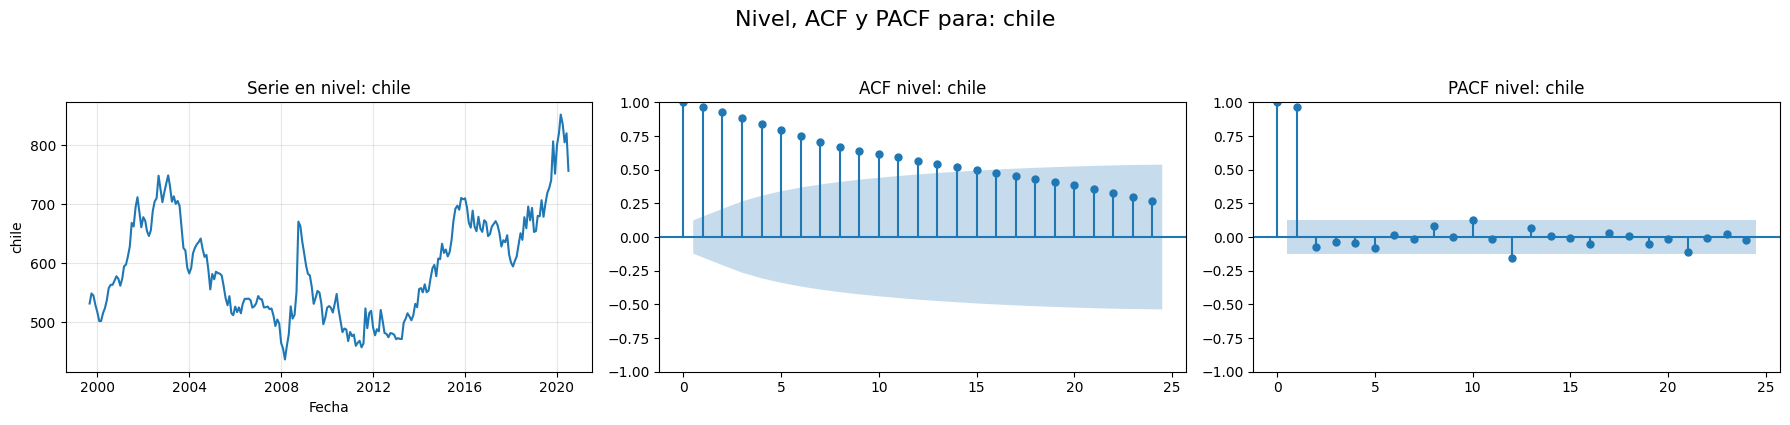

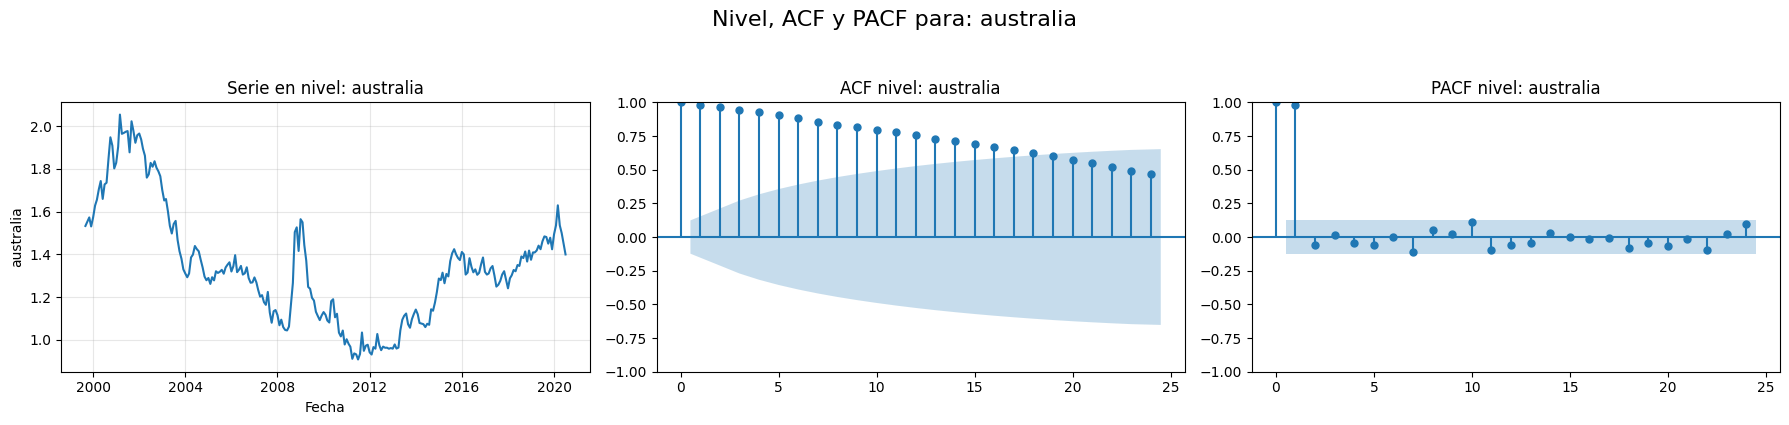

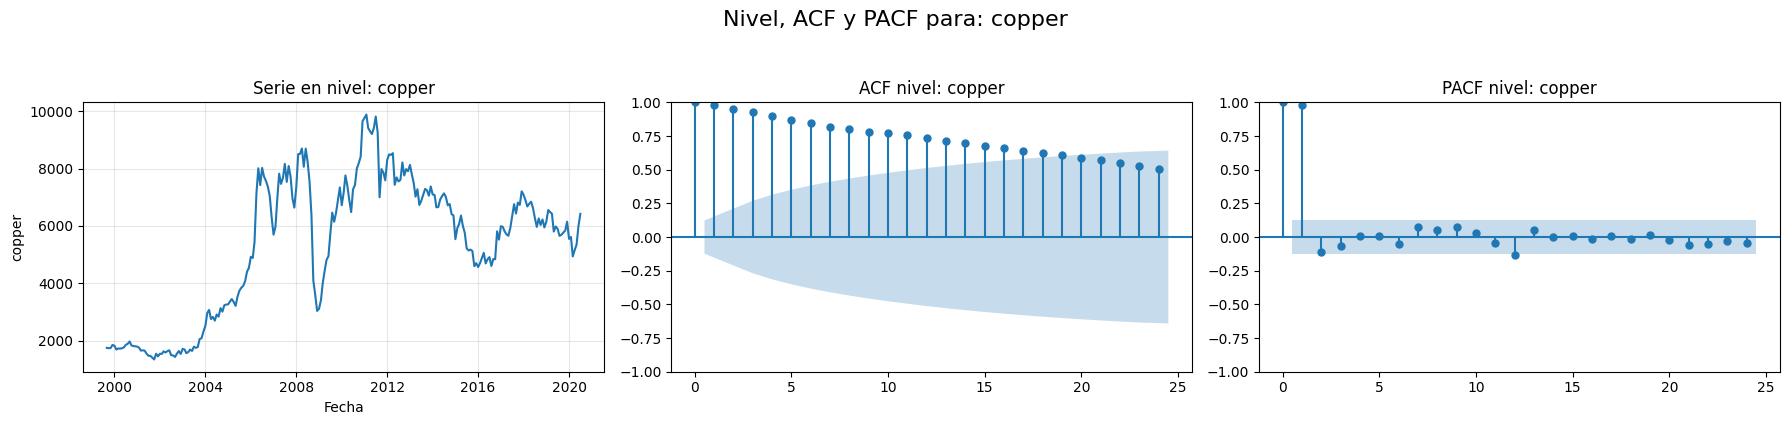

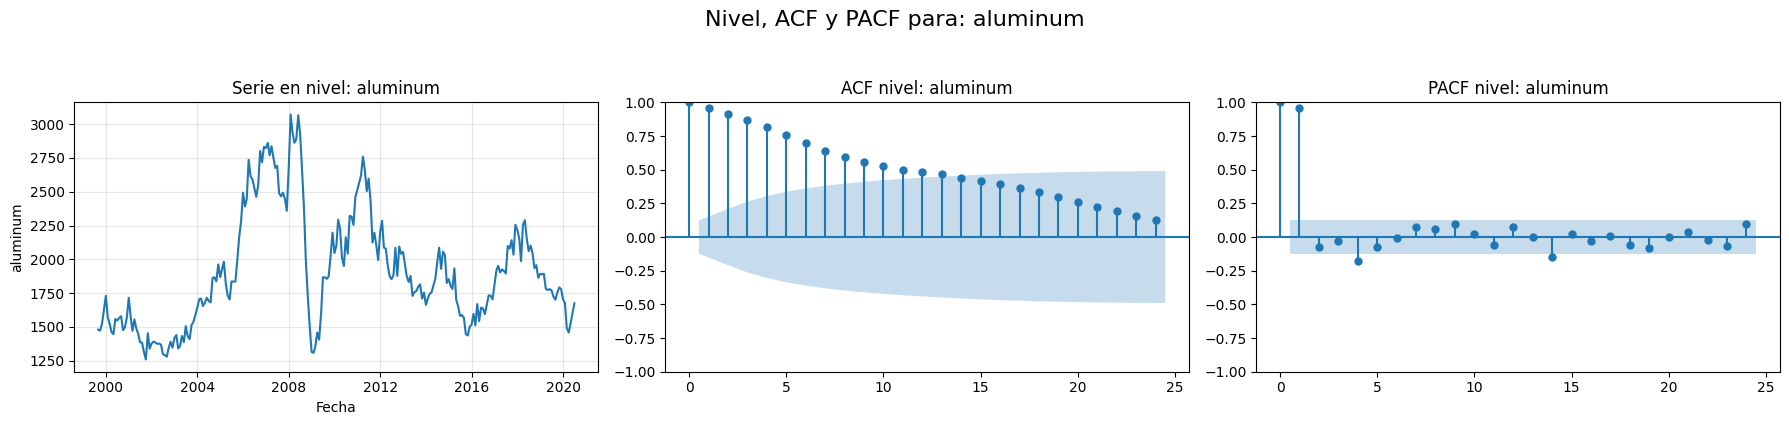

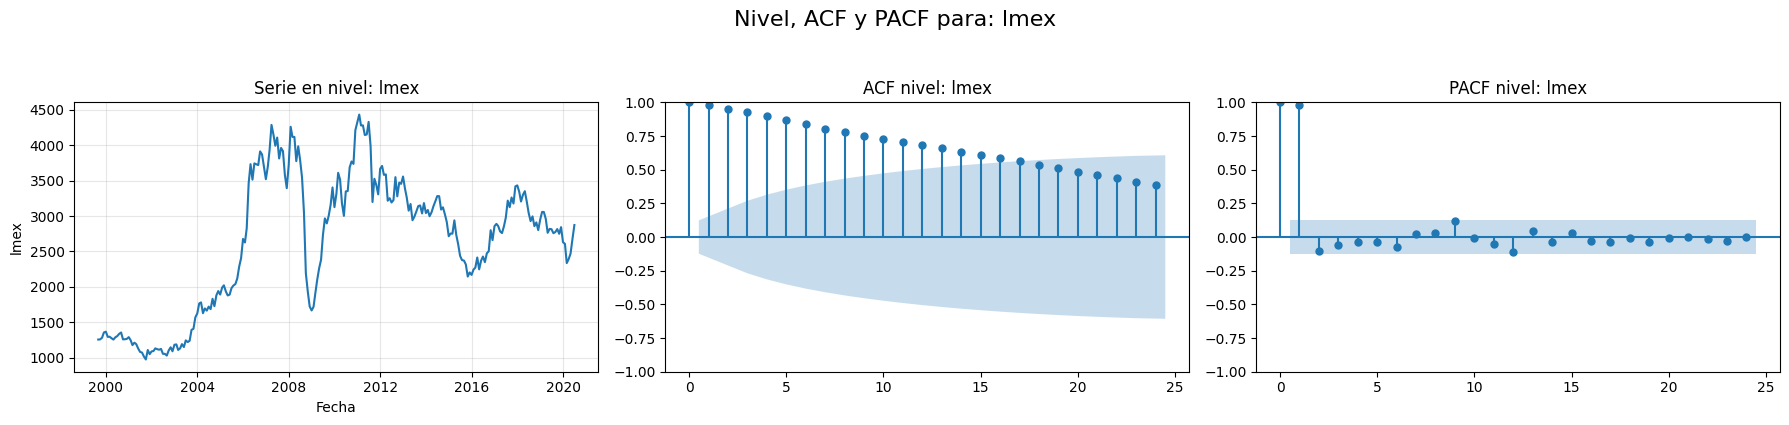

In [157]:
for col in series_a:
    serie = df[col].dropna()

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    
    # Título general para los 3 sub-gráficos
    fig.suptitle(f"Nivel, ACF y PACF para: {col}", fontsize=16, y=1.05)

    ax[0].plot(serie.index, serie)
    ax[0].set_title(f"Serie en nivel: {col}")
    ax[0].set_xlabel("Fecha")
    ax[0].set_ylabel(col)
    ax[0].grid(True, alpha=0.3)

    plot_acf(serie, lags=24, ax=ax[1])
    ax[1].set_title(f"ACF nivel: {col}")

    plot_pacf(serie, lags=24, ax=ax[2], method="ywm")
    ax[2].set_title(f"PACF nivel: {col}")
 
    plt.tight_layout()
    # Guardamos el archivo con el nombre de la serie correspondiente
    plt.savefig(os.path.join(GRAPHICS_DIR, f"grafico_1_Nivel_ACF_PACF_{col}.png"), bbox_inches='tight')
    plt.show()


### Bloque 5 - Logaritmo + ACF + PACF en una fila

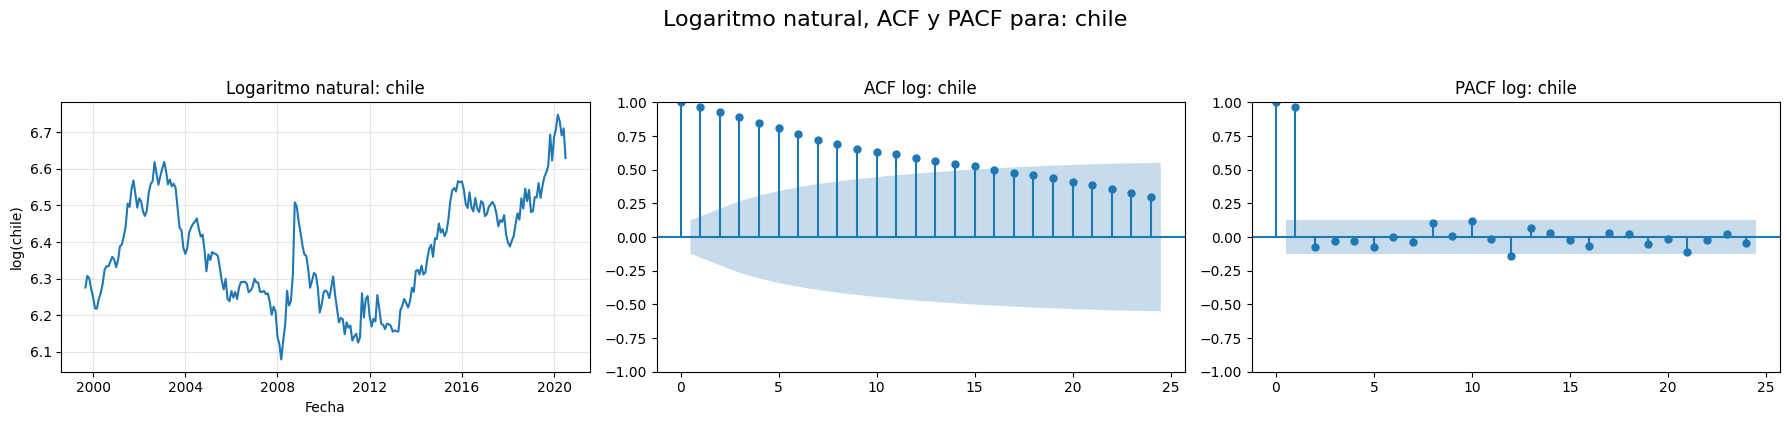

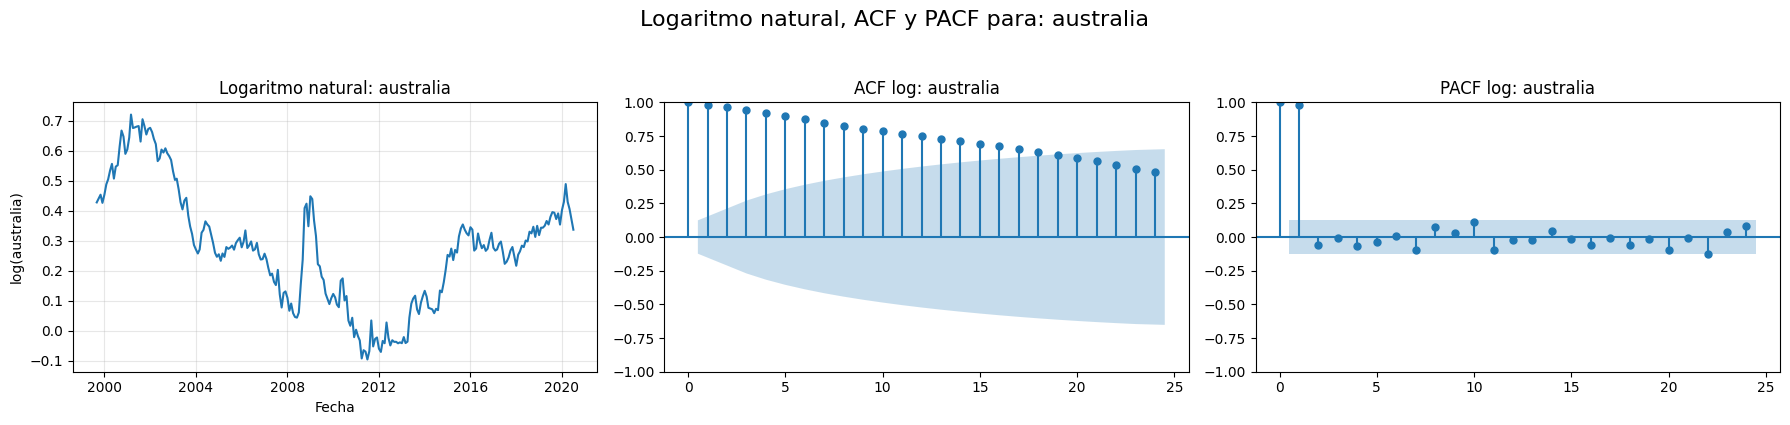

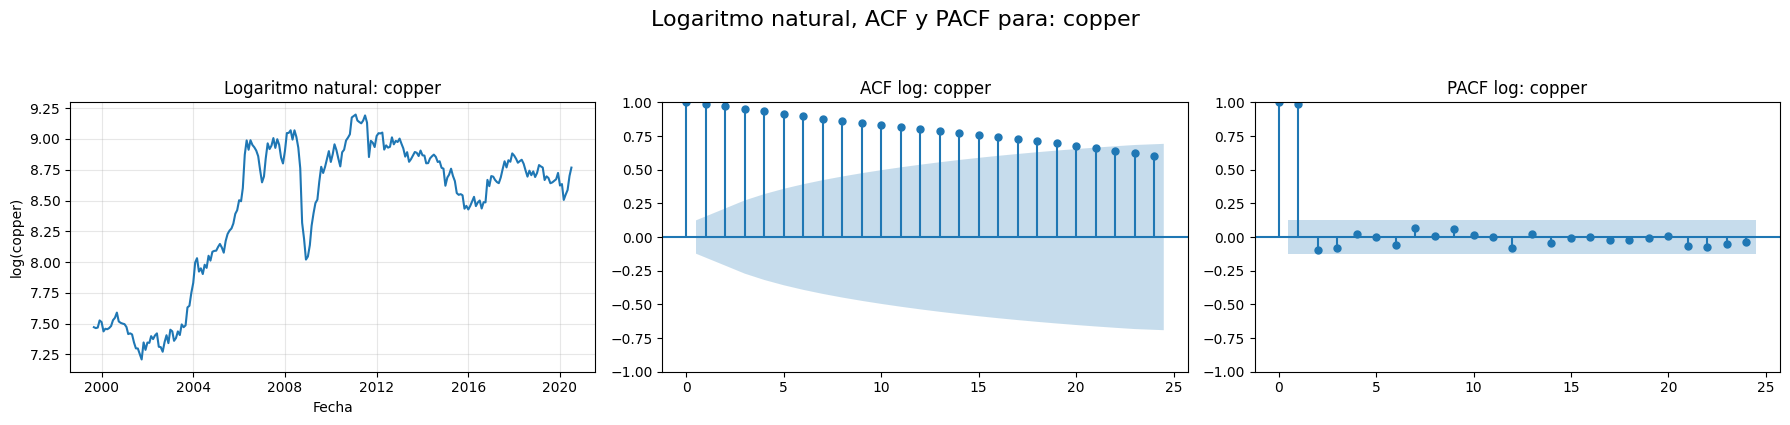

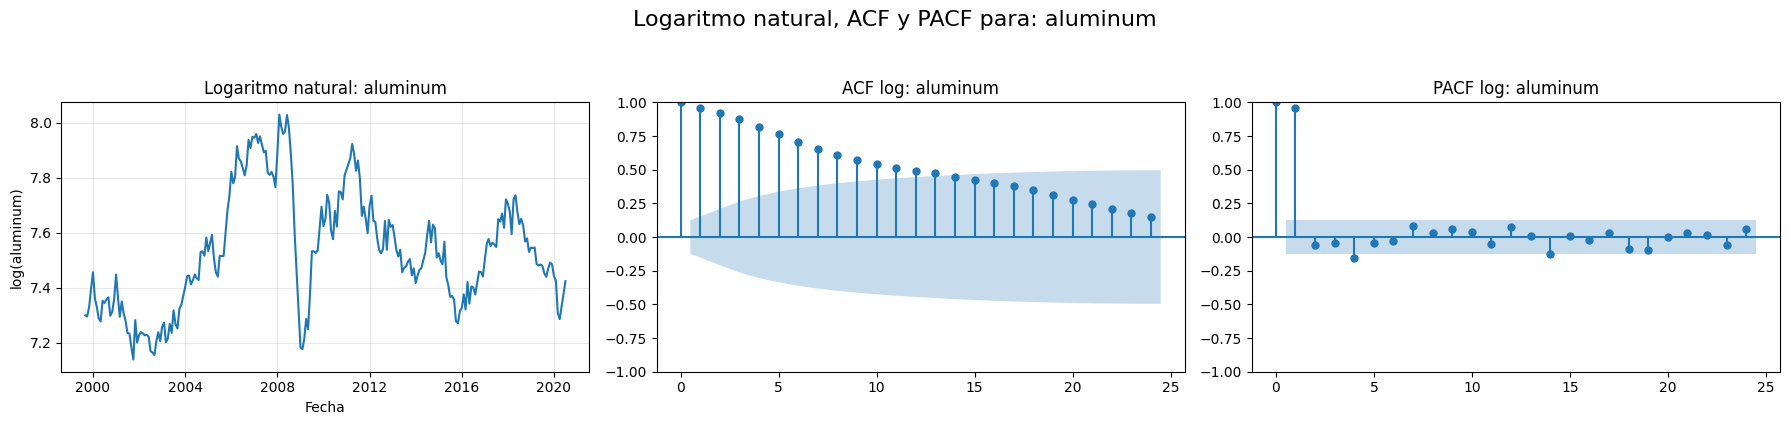

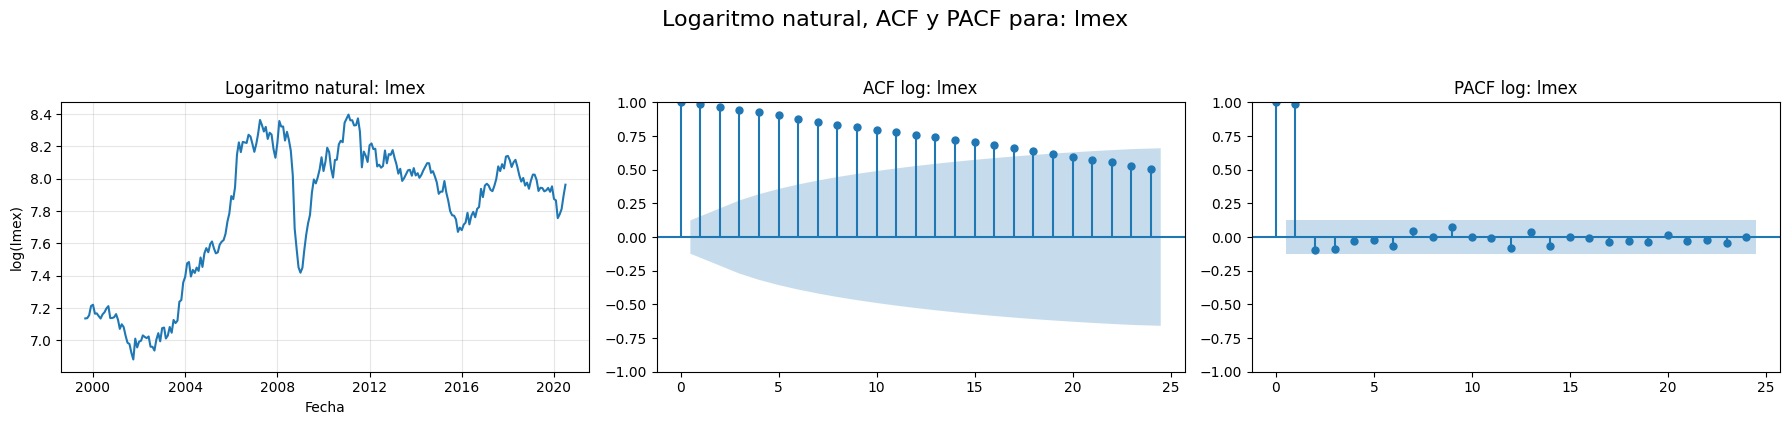

In [158]:
# Cálculo de los logaritmos (se mantiene igual)
for col in commodities + tipos_cambio:
    df[f"log_{col}"] = np.log(df[col])

# Ciclo para generar y guardar los gráficos
for col in series_a:
    log_col = f"log_{col}"
    serie = df[log_col].dropna()

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    
    # Título general para los 3 gráficos
    fig.suptitle(f"Logaritmo natural, ACF y PACF para: {col}", fontsize=16, y=1.05)

    ax[0].plot(serie.index, serie)
    ax[0].set_title(f"Logaritmo natural: {col}")
    ax[0].set_xlabel("Fecha")
    ax[0].set_ylabel(f"log({col})")
    ax[0].grid(True, alpha=0.3)

    plot_acf(serie, lags=24, ax=ax[1])
    ax[1].set_title(f"ACF log: {col}")

    plot_pacf(serie, lags=24, ax=ax[2], method="ywm")
    ax[2].set_title(f"PACF log: {col}")

    plt.tight_layout()
    
    # Guardamos cada gráfico de forma individual
    plt.savefig(os.path.join(GRAPHICS_DIR, f"grafico_2_Log_ACF_PACF_{col}.png"), bbox_inches='tight')
    plt.show()


## Respuesta A

Las series en nivel presentan alta persistencia temporal, lo que se refleja en correlogramas ACF con decaimiento lento. Al repetir el análisis en logaritmos, la escala cambia y las variaciones se interpretan en términos relativos, pero la estructura de persistencia se mantiene.

Por lo tanto, no se observan grandes diferencias entre los correlogramas de las series en nivel y en logaritmo. En ambos casos las series mantienen un comportamiento persistente, compatible con procesos no estacionarios o cercanos a raíz unitaria.

# Pregunta B: Primera diferencia logarítmica
### Bloque 7 - Retornos logarítmicos 1 mes

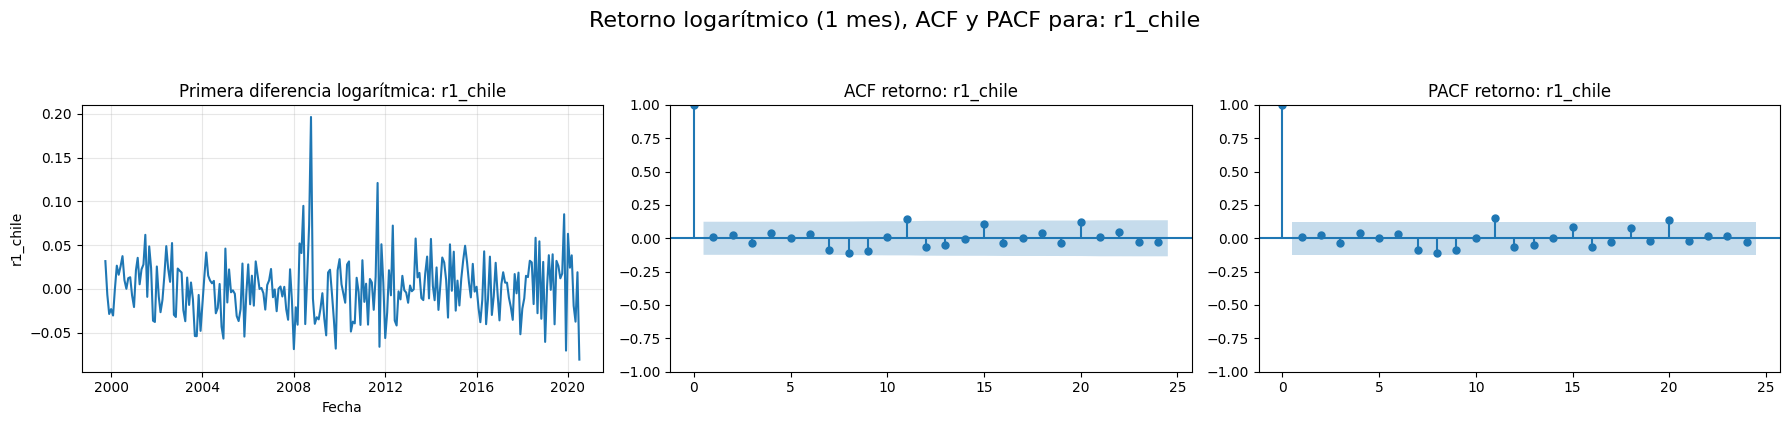

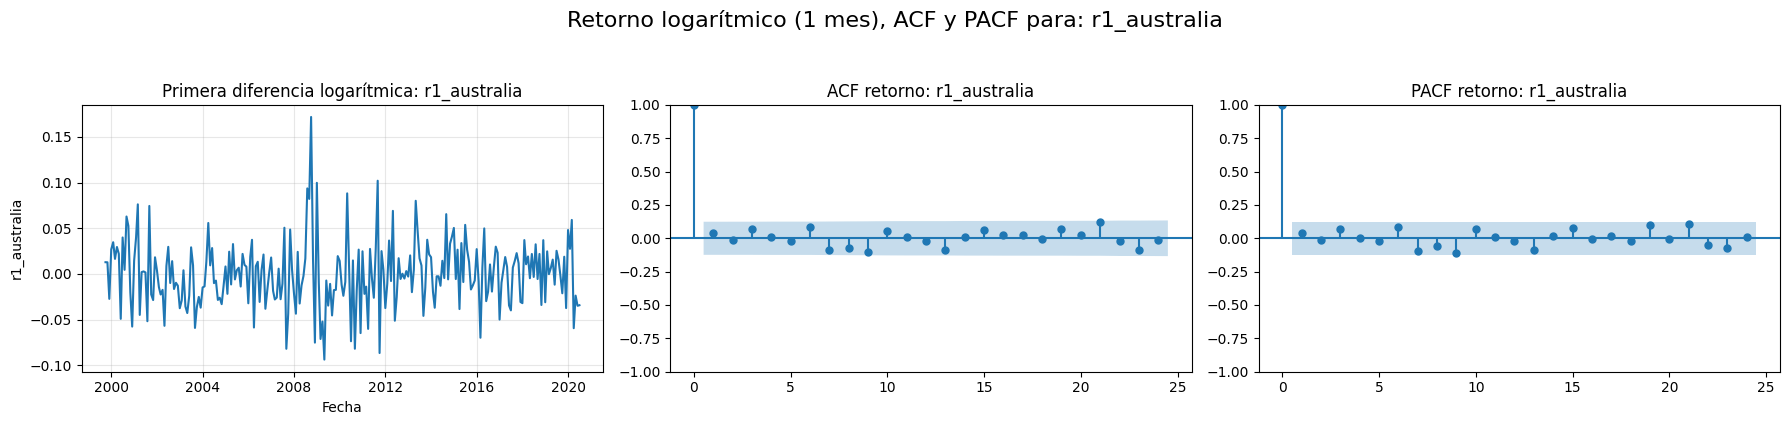

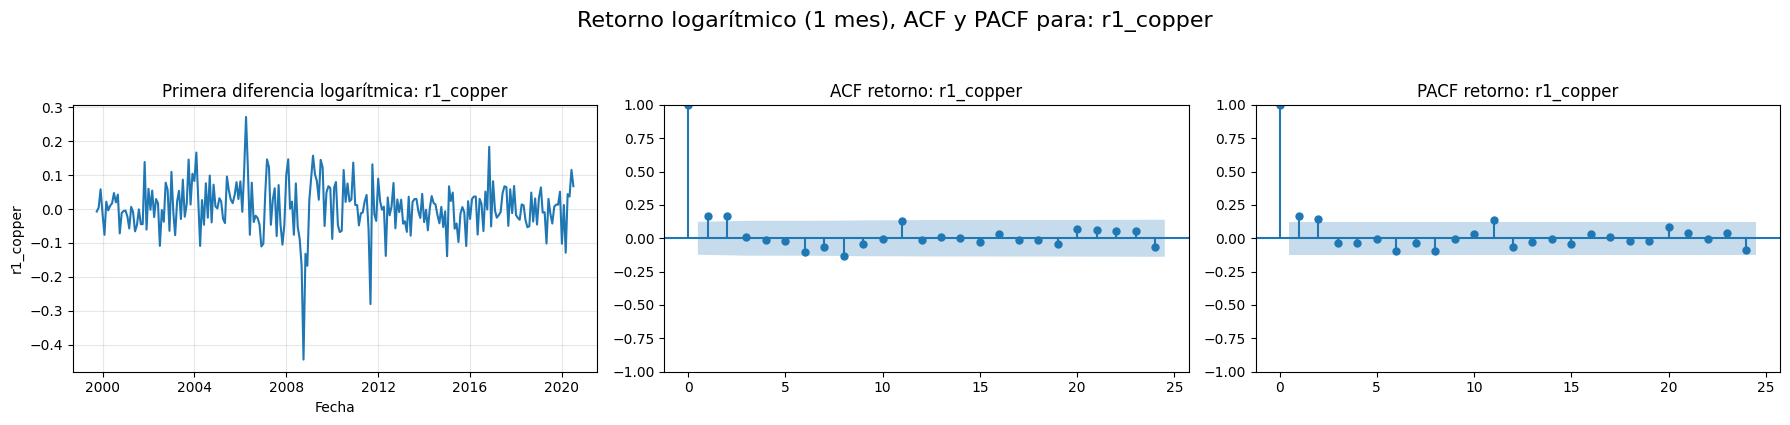

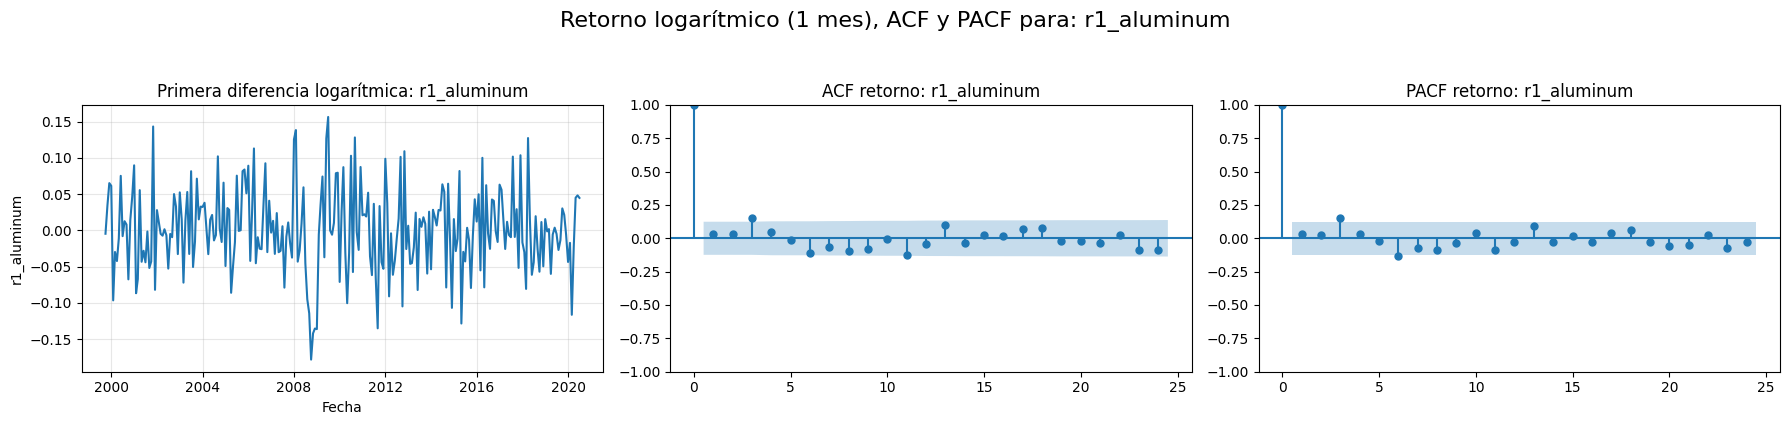

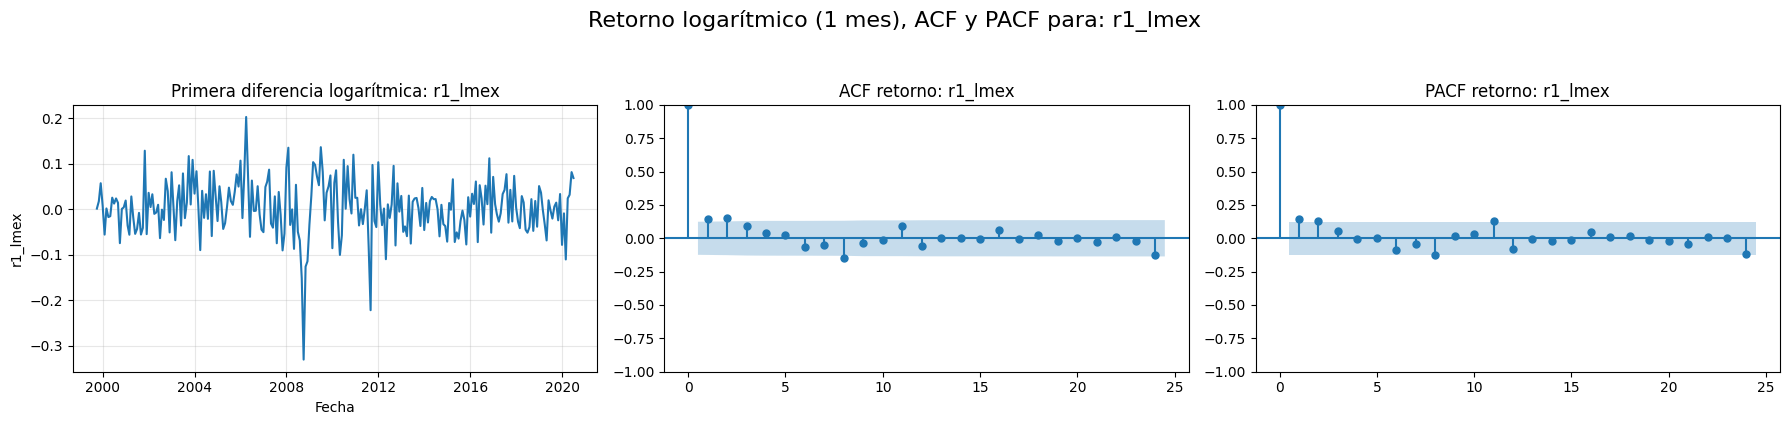

In [159]:
# Cálculo de la primera diferencia logarítmica (se mantiene igual)
for col in commodities + tipos_cambio:
    df[f"r1_{col}"] = df[f"log_{col}"] - df[f"log_{col}"].shift(1)

retornos_a = [f"r1_{col}" for col in series_a]

# Ciclo para generar y guardar los gráficos
for col in retornos_a:
    serie = df[col].dropna()

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    # Título general para los 3 gráficos
    fig.suptitle(f"Retorno logarítmico (1 mes), ACF y PACF para: {col}", fontsize=16, y=1.05)

    ax[0].plot(serie.index, serie)
    ax[0].set_title(f"Primera diferencia logarítmica: {col}")
    ax[0].set_xlabel("Fecha")
    ax[0].set_ylabel(col)
    ax[0].grid(True, alpha=0.3)

    plot_acf(serie, lags=24, ax=ax[1])
    ax[1].set_title(f"ACF retorno: {col}")

    plot_pacf(serie, lags=24, ax=ax[2], method="ywm")
    ax[2].set_title(f"PACF retorno: {col}")

    plt.tight_layout()
    
    # Guardamos cada gráfico de forma individual
    plt.savefig(os.path.join(GRAPHICS_DIR, f"grafico_3_Retornos_ACF_PACF_{col}.png"), bbox_inches='tight')
    plt.show()


### Bloque 8 - Test ADF

In [160]:
adf_resultados = []

for col in series_a:
    for transformacion, serie in {
        "nivel": df[col],
        "log": df[f"log_{col}"],
        "retorno_log": df[f"r1_{col}"]
    }.items():
        s = serie.dropna()

        adf = adfuller(s, autolag="AIC")

        adf_resultados.append({
            "serie": col,
            "transformacion": transformacion,
            "ADF_stat": adf[0],
            "p_value": adf[1],
            "rechaza_raiz_unitaria_5pct": adf[1] < 0.05
        })

adf_df = pd.DataFrame(adf_resultados)
adf_df

,serie,transformacion,ADF_stat,p_value,rechaza_raiz_unitaria_5pct
0,chile,nivel,-1.458942,5.537157e-01,False
1,chile,log,-1.498246,5.343787e-01,False
2,chile,retorno_log,-15.409554,3.136687e-28,True
3,australia,nivel,-1.518794,5.241945e-01,False
4,australia,log,-1.541159,5.130615e-01,False
5,australia,retorno_log,-15.074380,8.632829e-28,True
6,copper,nivel,-2.083950,2.510173e-01,False
7,copper,log,-1.821413,3.698836e-01,False
8,copper,retorno_log,-8.665828,4.687543e-14,True
9,aluminum,nivel,-2.283728,1.772699e-01,False


## Respuesta B
Al trabajar con primeras diferencias logarítmicas, la persistencia observada en las series disminuye considerablemente. Los correlogramas de los retornos muestran autocorrelaciones más acotadas y de rápida disipación.

Esto sugiere que las series en retornos son más compatibles con estacionariedad que las series en nivel o en logaritmo. Por lo tanto, para la modelación predictiva se trabajará con retornos logarítmicos.

# Pregunta C: Retornos a 1 y 12 meses para toda la base
### Bloque 10 - Construir retornos 1M y 12M

In [161]:
todas_series = commodities + tipos_cambio

for col in todas_series:
    df[f"r1_{col}"] = np.log(df[col]) - np.log(df[col].shift(1))
    df[f"r12_{col}"] = np.log(df[col]) - np.log(df[col].shift(12))

print("Retornos creados correctamente para:")
print(todas_series)

Retornos creados correctamente para:
['tin', 'nickel', 'lmex', 'lead', 'copper', 'aluminum', 'southafrica', 'newzealand', 'chile', 'canada', 'australia']


### Bloque 11 - Correlograma retornos 1M y 12M

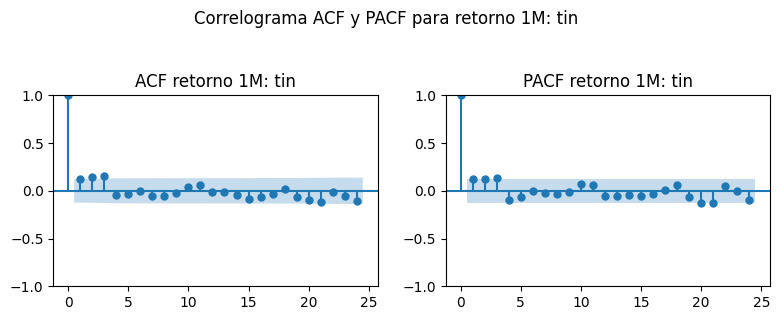

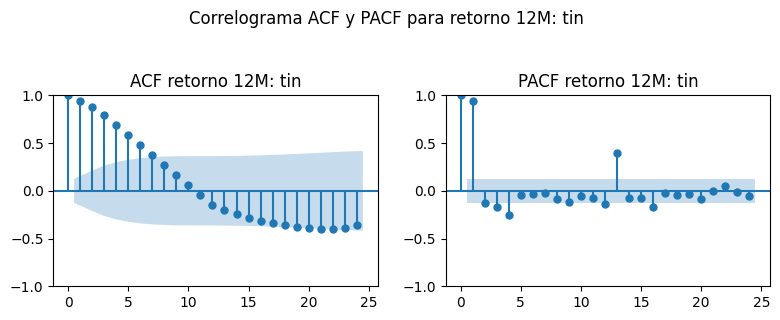

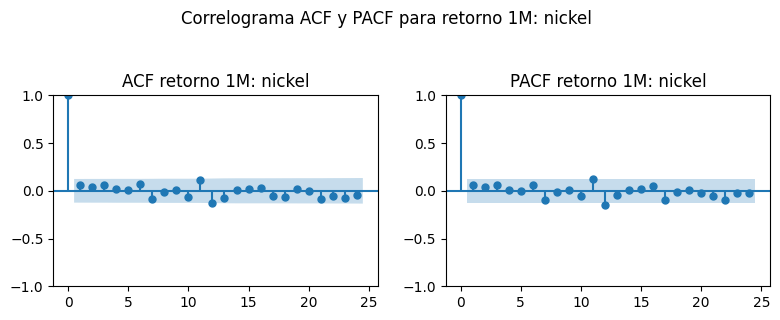

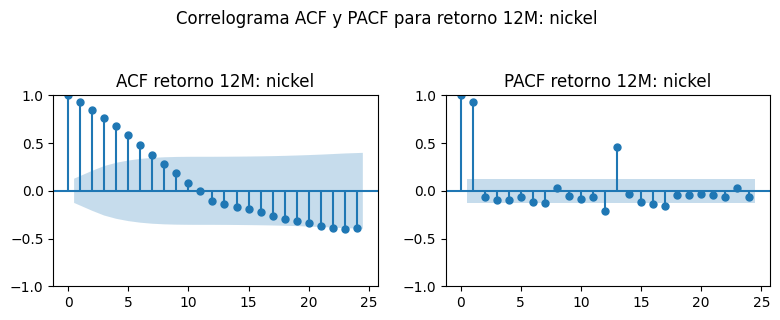

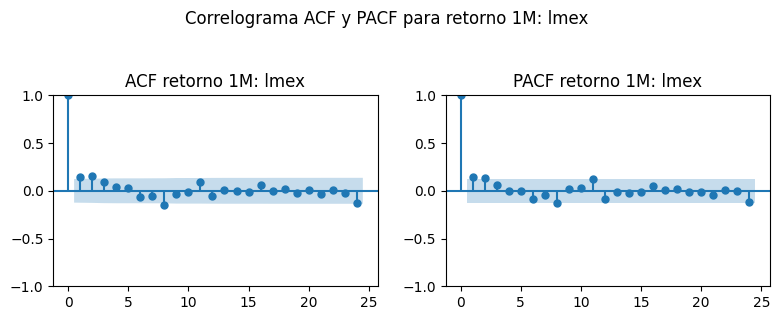

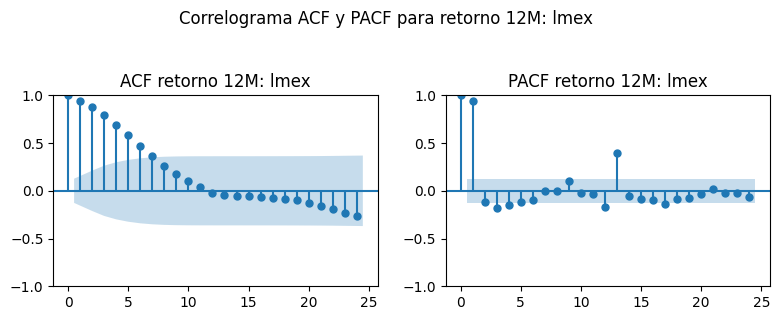

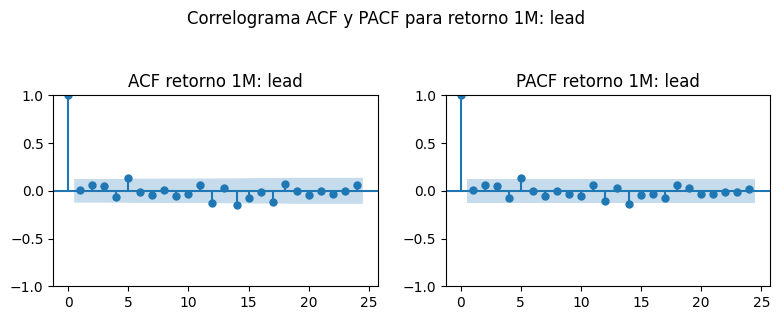

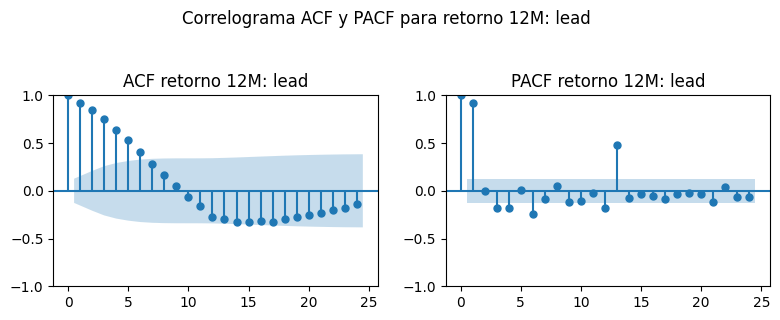

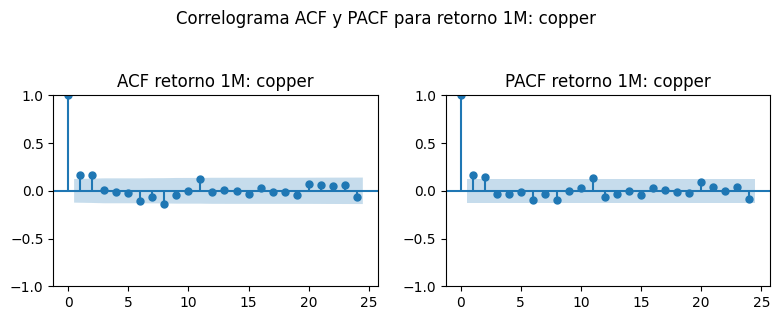

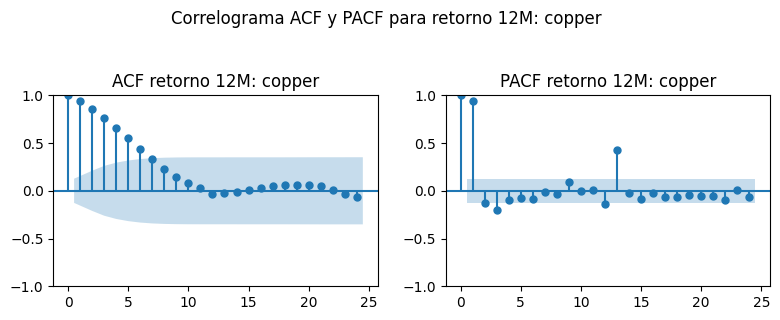

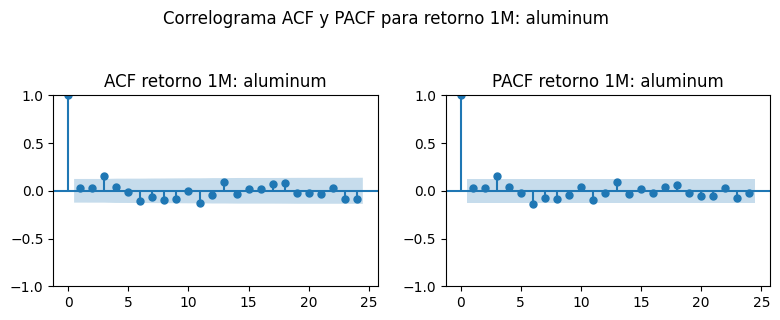

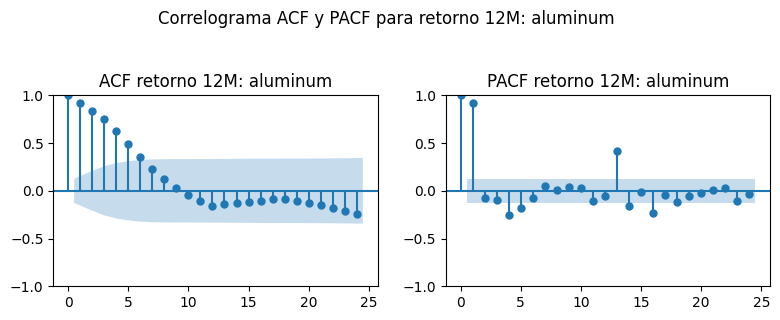

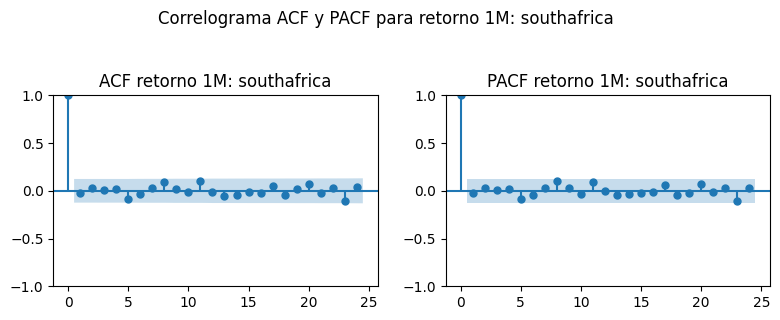

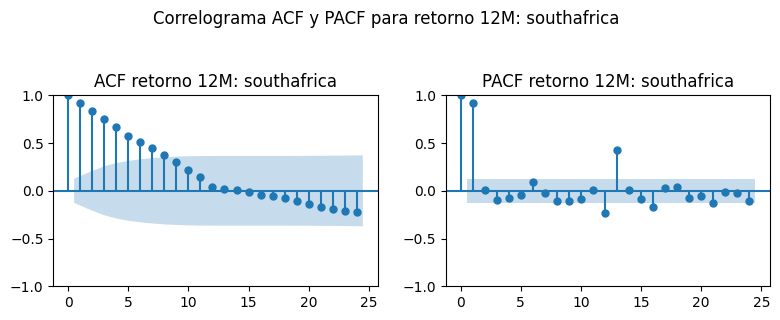

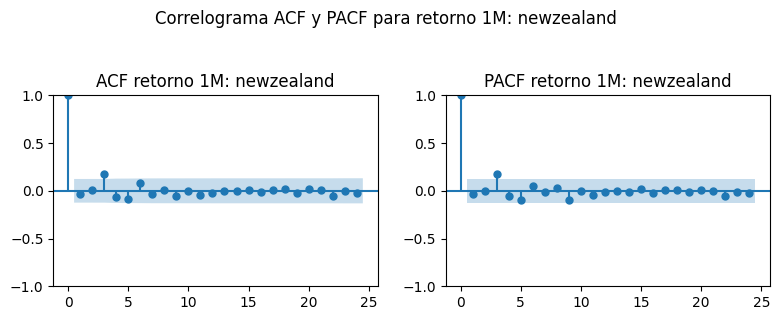

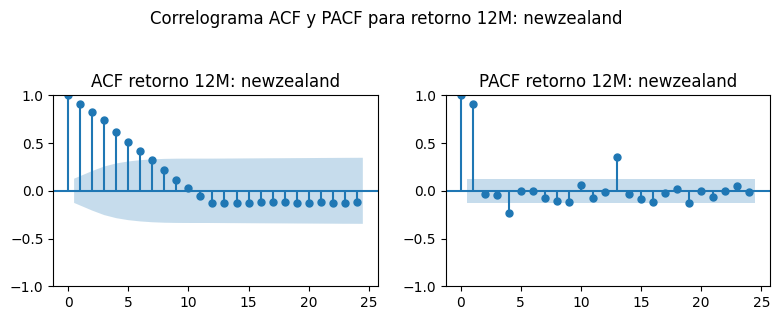

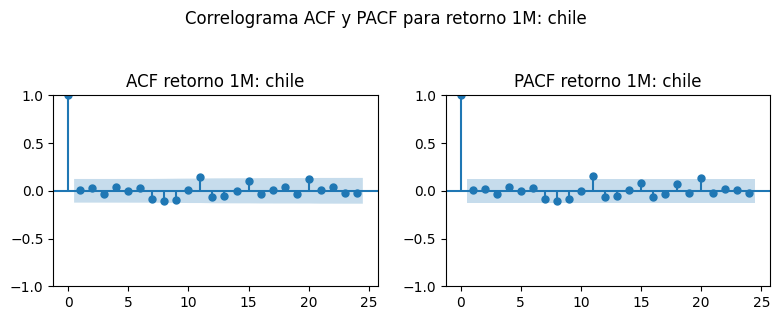

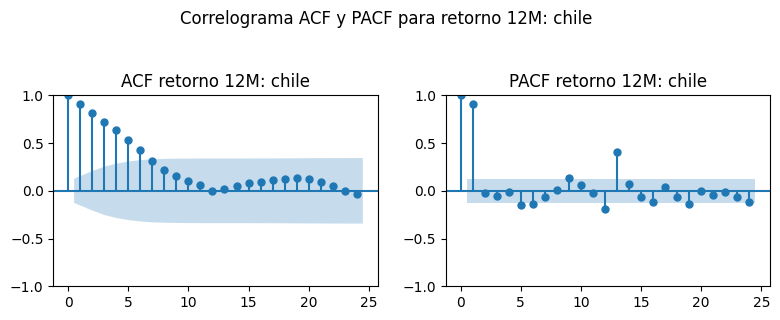

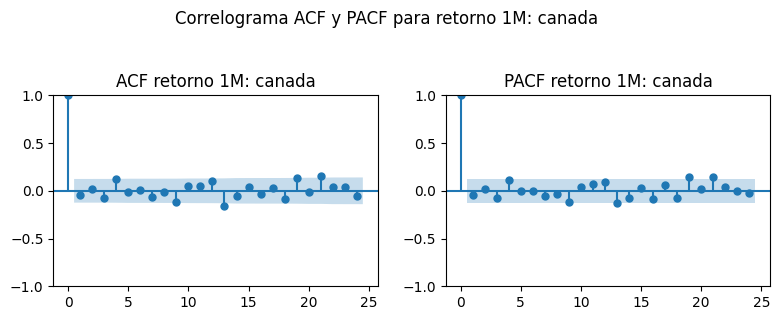

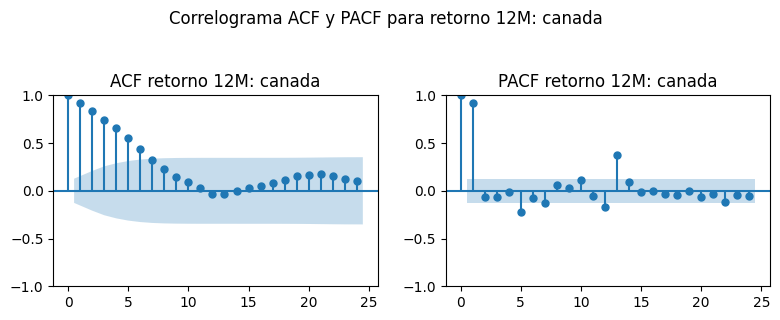

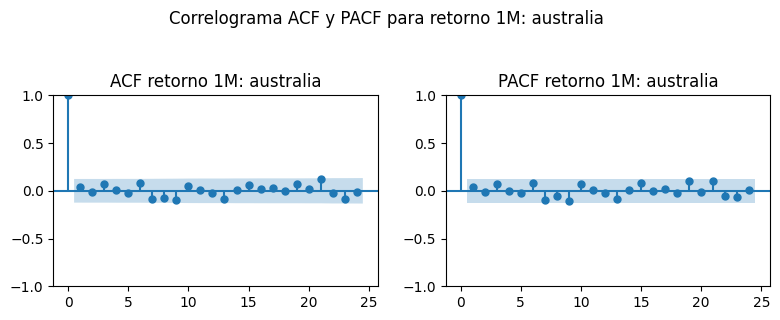

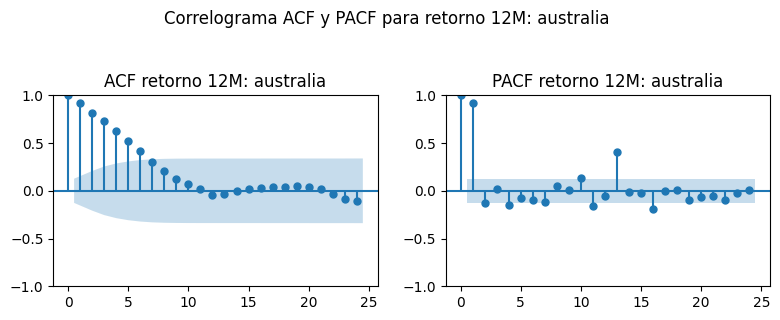

In [162]:
for col in todas_series:
    for h in [1, 12]:
        r_col = f"r{h}_{col}"
        serie = df[r_col].dropna()

        fig, ax = plt.subplots(1, 2, figsize=(8, 3))

        # Título general para la figura
        fig.suptitle(f"Correlograma ACF y PACF para retorno {h}M: {col}", fontsize=12, y=1.05)

        plot_acf(serie, lags=24, ax=ax[0])
        plot_pacf(serie, lags=24, ax=ax[1], method="ywm")

        ax[0].set_title(f"ACF retorno {h}M: {col}")
        ax[1].set_title(f"PACF retorno {h}M: {col}")

        plt.tight_layout()
        
        # Guardamos el gráfico usando {col} y {h} para que el nombre sea único
        plt.savefig(os.path.join(GRAPHICS_DIR, f"grafico_4_Correlograma_{h}M_{col}.png"), bbox_inches='tight')
        plt.show()


### Respuesta C

Los retornos a 1 mes presentan baja persistencia, con autocorrelaciones acotadas y de rápida disipación. Esto es consistente con la literatura financiera, donde los retornos suelen ser difíciles de predecir usando únicamente su propia historia.

Los retornos a 12 meses muestran mayor persistencia, principalmente porque son retornos acumulados y comparten observaciones entre períodos consecutivos. Esto genera autocorrelación mecánica por superposición de ventanas.

Por lo tanto, sí existen diferencias entre los correlogramas de retornos a 1 y 12 meses. Los retornos anuales tienden a mostrar mayor persistencia que los retornos mensuales.

# Pregunta D: Histogramas y Normalidad
### Bloque 13 - Histogramas

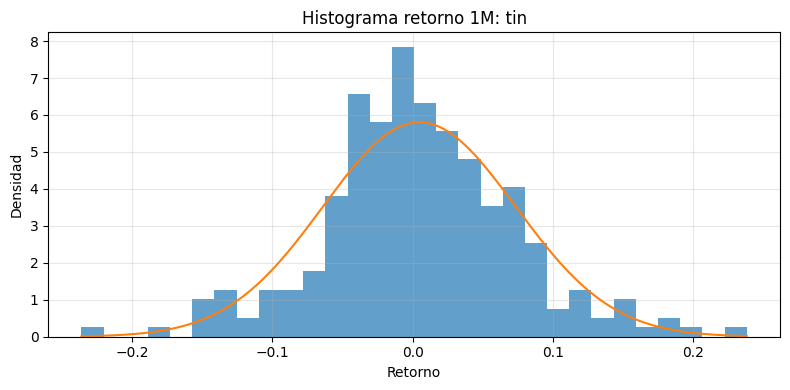

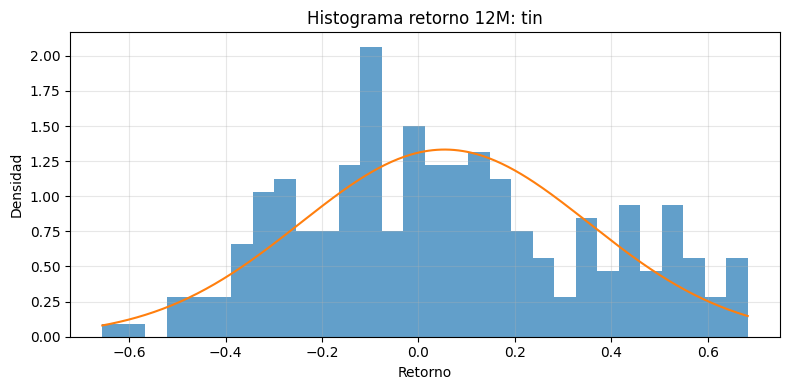

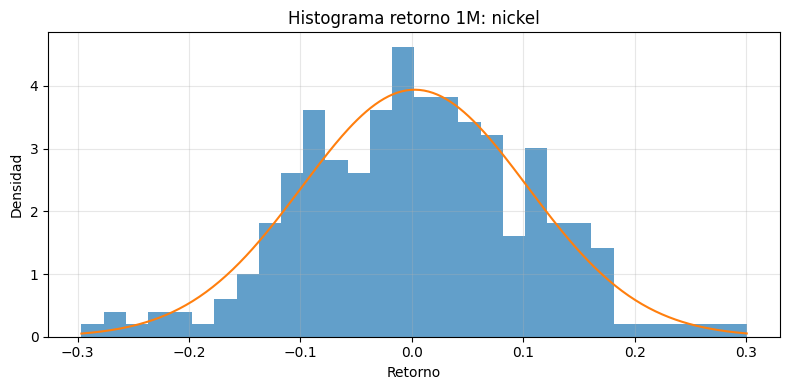

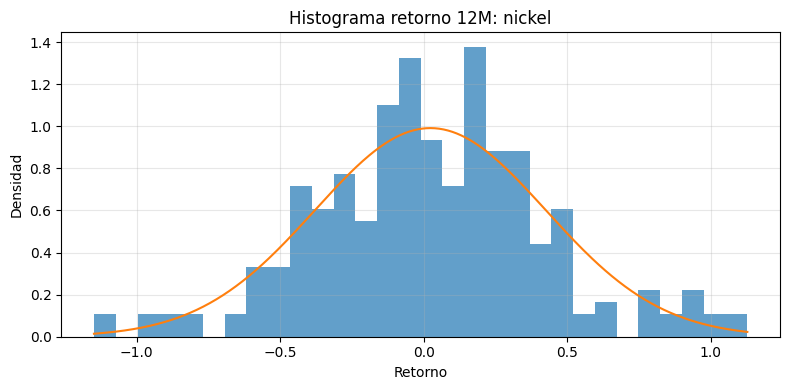

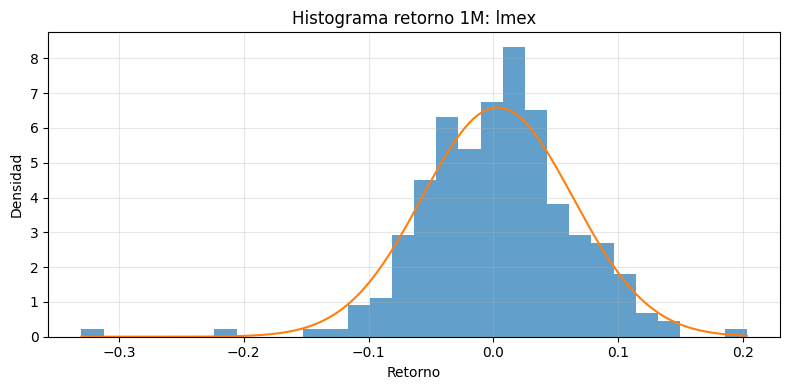

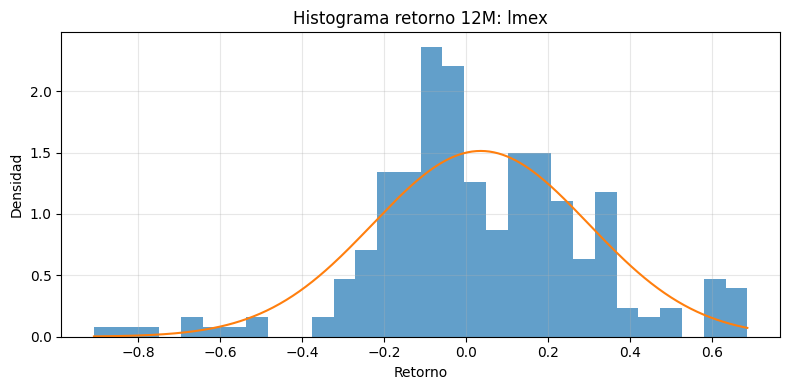

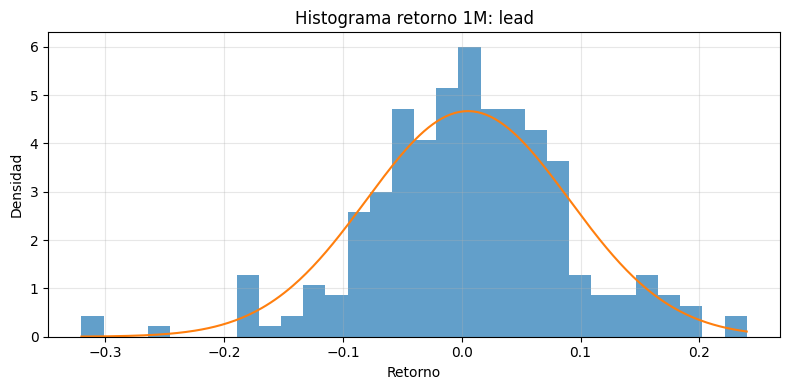

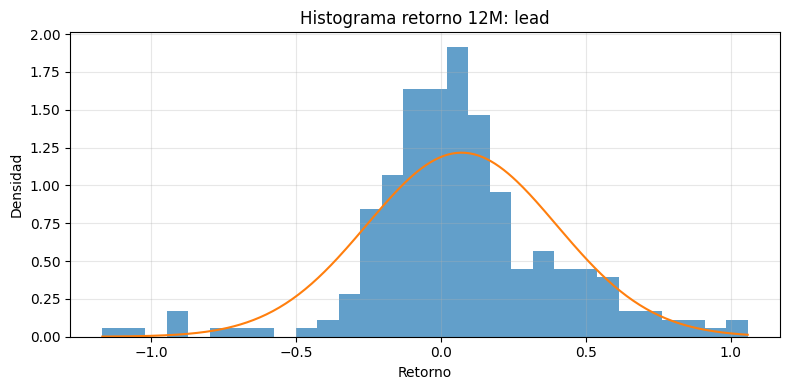

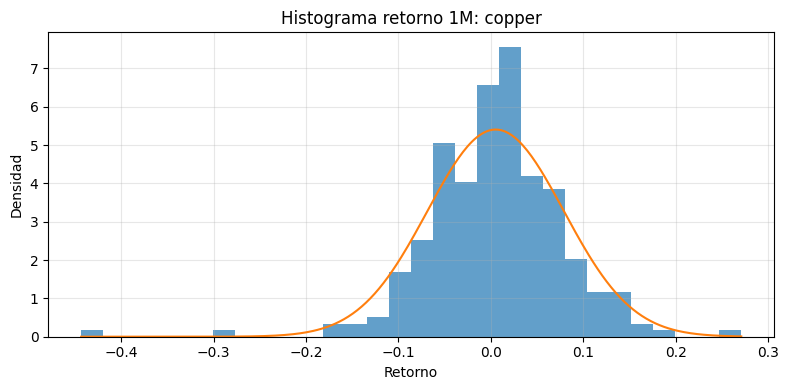

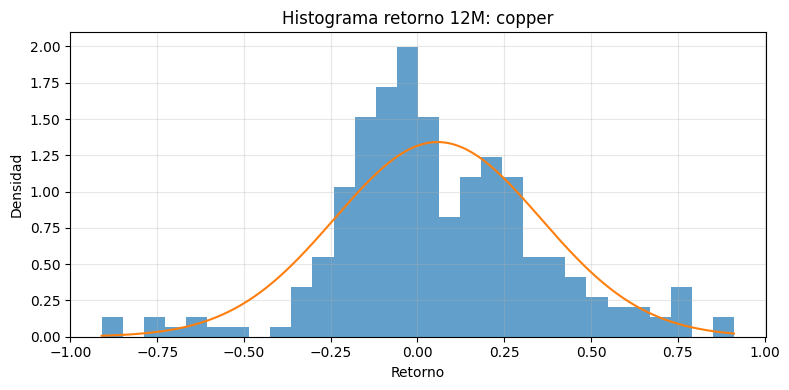

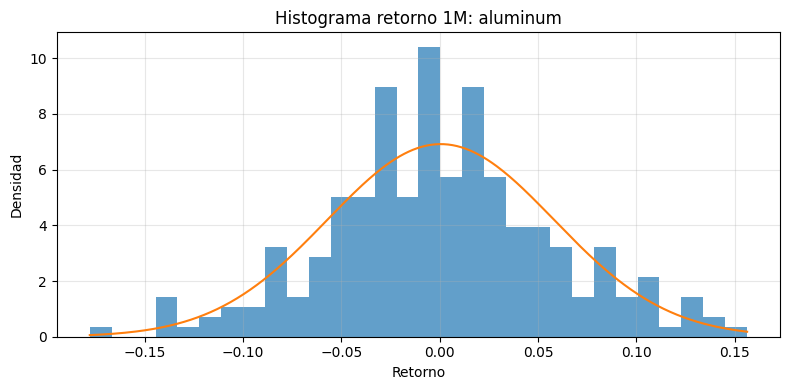

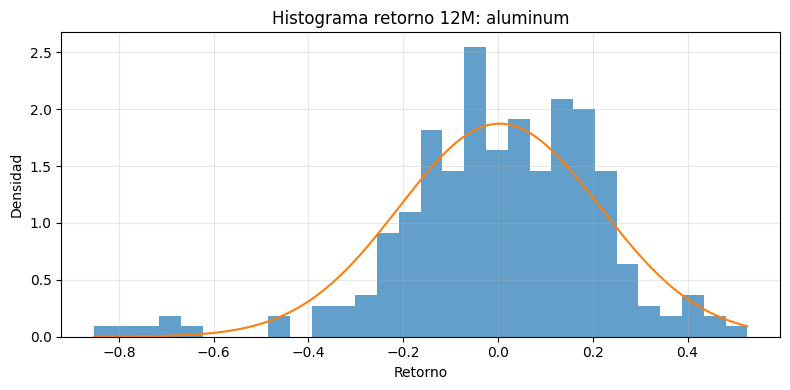

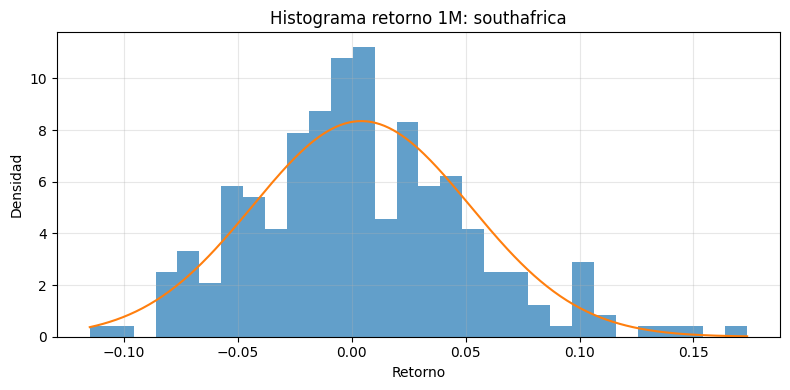

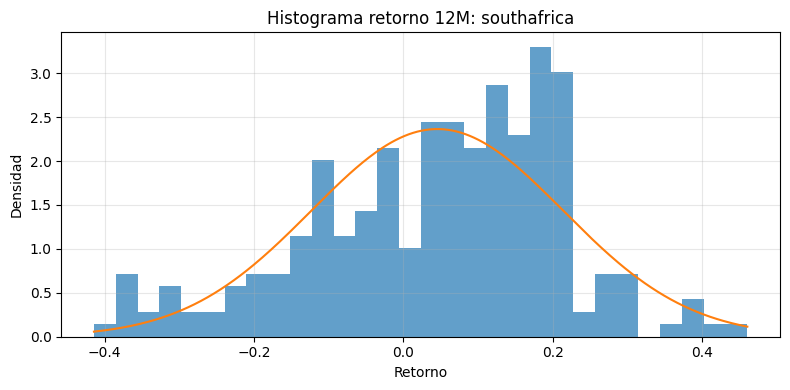

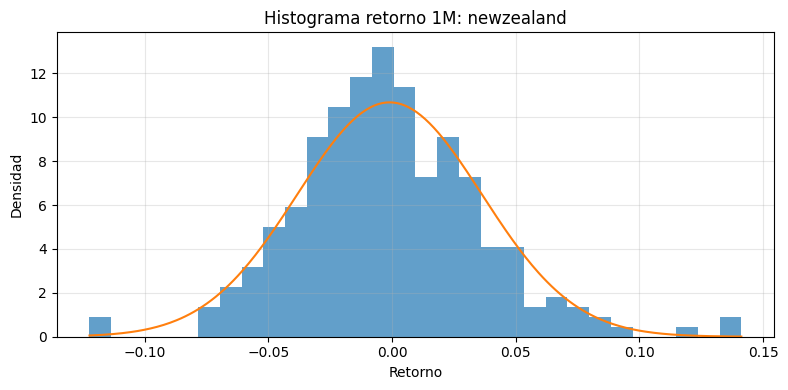

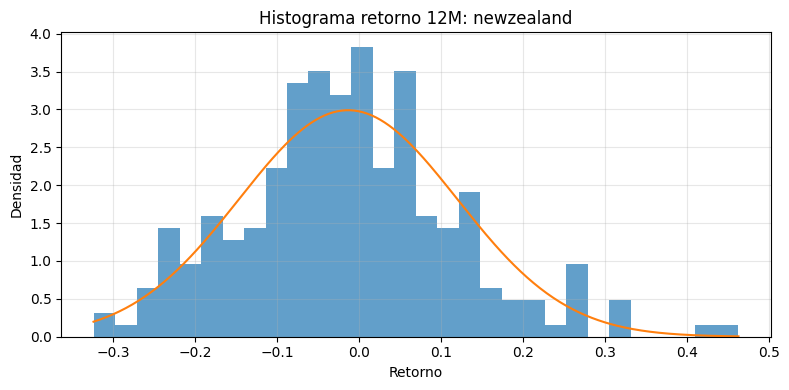

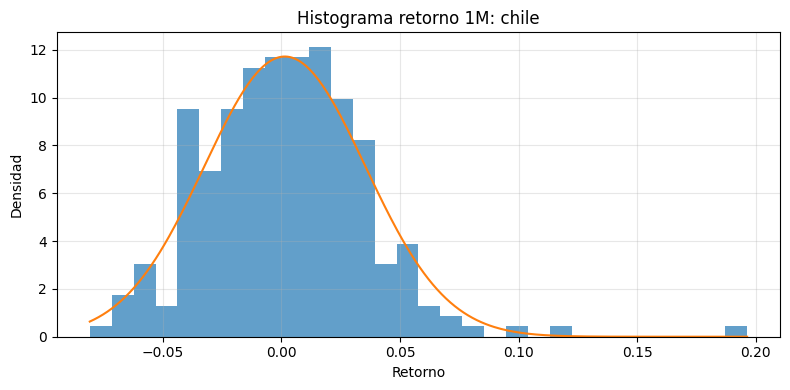

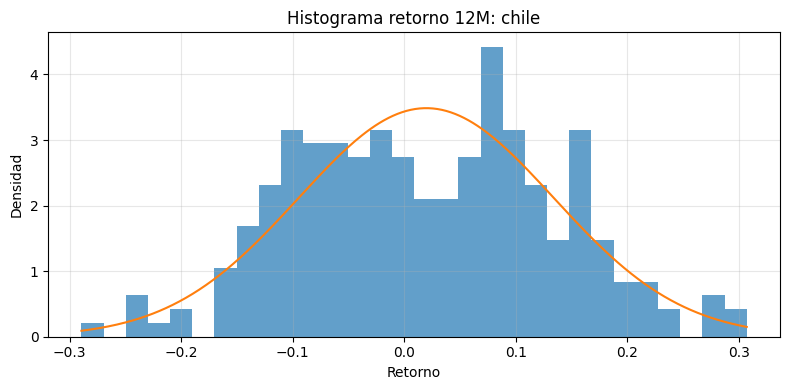

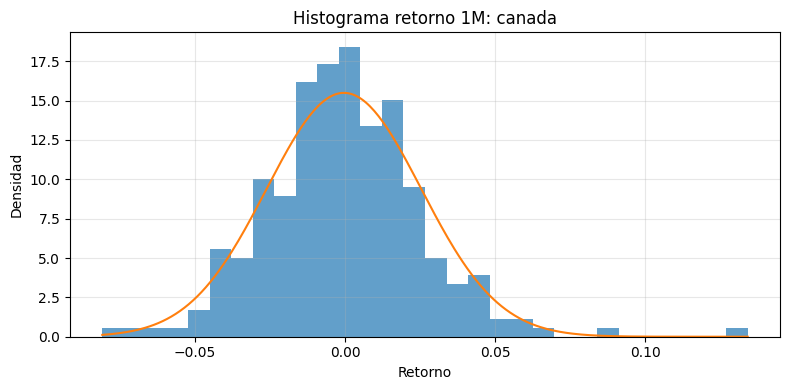

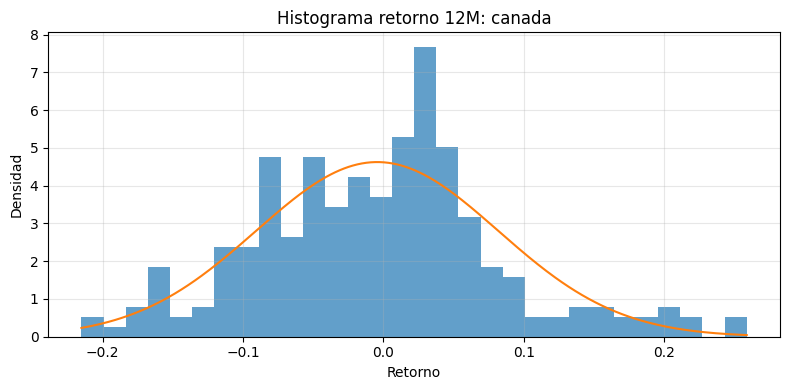

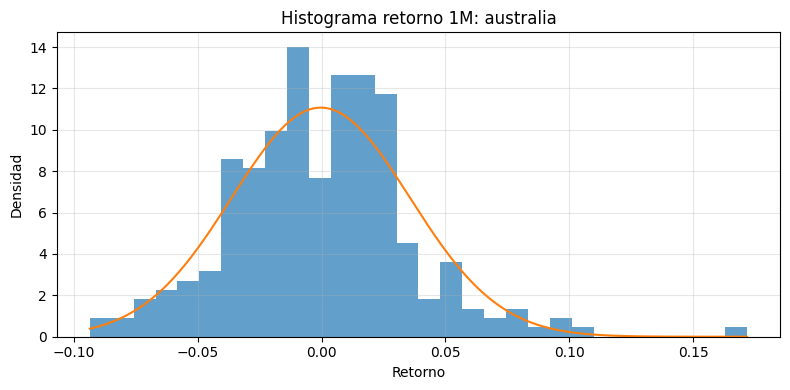

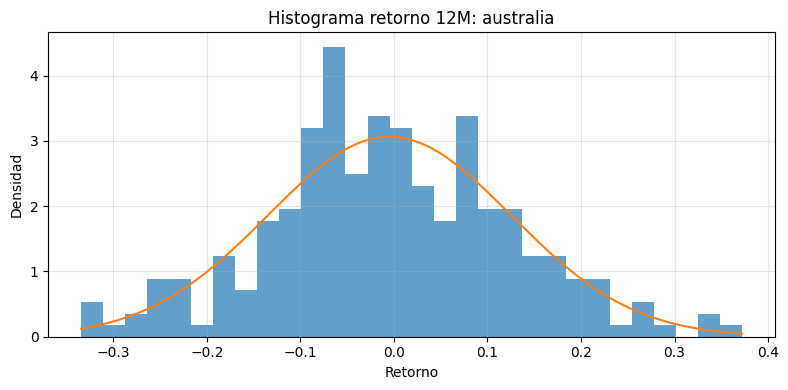

In [163]:
for col in todas_series:
    for h in [1, 12]:
        r_col = f"r{h}_{col}"
        serie = df[r_col].dropna()

        plt.figure(figsize=(8, 4))
        plt.hist(serie, bins=30, density=True, alpha=0.7)

        x = np.linspace(serie.min(), serie.max(), 300)
        plt.plot(x, stats.norm.pdf(x, serie.mean(), serie.std()))

        plt.title(f"Histograma retorno {h}M: {col}")
        plt.xlabel("Retorno")
        plt.ylabel("Densidad")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Guardamos el gráfico usando {h} y {col} en el nombre
        plt.savefig(os.path.join(GRAPHICS_DIR, f"grafico_5_Histograma_{h}M_{col}.png"), bbox_inches='tight')
        plt.show()


### Bloque 13 - Jarque - Bera

In [164]:
normalidad = []

for col in todas_series:
    for h in [1, 12]:
        r_col = f"r{h}_{col}"
        serie = df[r_col].dropna()

        jb = stats.jarque_bera(serie)

        normalidad.append({
            "serie": col,
            "horizonte": h,
            "media": serie.mean(),
            "desv_std": serie.std(),
            "asimetria": stats.skew(serie),
            "curtosis": stats.kurtosis(serie, fisher=False),
            "JB_stat": jb.statistic,
            "JB_pvalue": jb.pvalue,
            "rechaza_normalidad_5pct": jb.pvalue < 0.05
        })

normalidad_df = pd.DataFrame(normalidad)
normalidad_df

,serie,horizonte,media,desv_std,asimetria,curtosis,JB_stat,JB_pvalue,rechaza_normalidad_5pct
0,tin,1,0.004803,0.068748,0.096864,3.954775,9.886722,7.130591e-03,True
1,tin,12,0.054230,0.299432,0.212603,2.287769,6.852061,3.251575e-02,True
2,nickel,1,0.002598,0.101278,-0.064414,3.136665,0.367435,8.321707e-01,False
3,nickel,12,0.023411,0.402318,0.055966,3.483946,2.457045,2.927248e-01,False
4,lmex,1,0.003310,0.060557,-0.636614,6.629955,154.142502,3.375834e-34,True
5,lmex,12,0.036000,0.263569,-0.172727,4.218817,15.981664,3.385523e-04,True
6,lead,1,0.005247,0.085429,-0.351336,4.402180,25.623503,2.728519e-06,True
7,lead,12,0.070751,0.328004,-0.117256,5.104505,44.652554,2.012895e-10,True
8,copper,1,0.005187,0.073823,-0.854492,8.752726,375.150930,3.443584e-82,True
9,copper,12,0.058158,0.297419,0.058471,4.045373,11.018689,4.048761e-03,True


## Respuesta D

Los histogramas muestran que los retornos no siempre se comportan como una distribución normal. En varias series se observan colas pesadas, asimetrías y observaciones extremas, lo que es habitual en retornos financieros y de commodities.

El test de Jarque-Bera permite complementar esta evaluación visual. Cuando el p-value es menor a 0.05, se rechaza la hipótesis nula de normalidad. Por tanto, si varias series rechazan normalidad, los retornos no son plenamente consistentes con el supuesto normal.

# Pregunta E: Modelo CRR con Errores usuales
### Bloque 16 - Función CRR usual

In [165]:
def estimar_crr_usual(df, commodity, tipo_cambio):
    data = pd.DataFrame({
        "y": df[f"r1_{commodity}"],
        "y_lag1": df[f"r1_{commodity}"].shift(1),
        "tc_lag1": df[f"r1_{tipo_cambio}"].shift(1)
    }).dropna()

    X_base = sm.add_constant(data[["y_lag1"]], has_constant="add")
    X_fx = sm.add_constant(data[["y_lag1", "tc_lag1"]], has_constant="add")

    modelo_base = sm.OLS(data["y"], X_base).fit()
    modelo_fx = sm.OLS(data["y"], X_fx).fit()

    return modelo_base, modelo_fx

### Bloque 17 - Estimar CRR para 2 TC y 3 commodities

In [166]:
commodities_e = ["copper", "aluminum", "lmex"]
tipos_cambio_e = ["chile", "australia"]

commodities_e = [c for c in commodities_e if c in commodities]
tipos_cambio_e = [tc for tc in tipos_cambio_e if tc in tipos_cambio]

resultados_e = []

for c in commodities_e:
    for tc in tipos_cambio_e:
        modelo_base, modelo_fx = estimar_crr_usual(df, c, tc)

        resultados_e.append({
            "commodity": c,
            "tipo_cambio": tc,
            "rho_AR": modelo_fx.params["y_lag1"],
            "pvalue_rho_AR": modelo_fx.pvalues["y_lag1"],
            "rho_significativo_5pct": modelo_fx.pvalues["y_lag1"] < 0.05,
            "beta_TC": modelo_fx.params["tc_lag1"],
            "pvalue_beta_TC": modelo_fx.pvalues["tc_lag1"],
            "beta_TC_significativo_5pct": modelo_fx.pvalues["tc_lag1"] < 0.05,
            "R2_sin_TC": modelo_base.rsquared,
            "R2_con_TC": modelo_fx.rsquared,
            "aumento_R2": modelo_fx.rsquared - modelo_base.rsquared
        })

resultados_e_df = pd.DataFrame(resultados_e)
resultados_e_df

,commodity,tipo_cambio,rho_AR,pvalue_rho_AR,rho_significativo_5pct,beta_TC,pvalue_beta_TC,beta_TC_significativo_5pct,R2_sin_TC,R2_con_TC,aumento_R2
0,copper,chile,0.116557,0.110644,False,-0.206744,0.196212,False,0.026939,0.033537,0.006598
1,copper,australia,0.119035,0.119461,False,-0.164259,0.293770,False,0.026939,0.031298,0.004359
2,aluminum,chile,-0.028432,0.675007,False,-0.288335,0.013607,True,0.001106,0.025574,0.024468
3,aluminum,australia,-0.065007,0.368615,False,-0.319944,0.006077,True,0.001106,0.031269,0.030163
4,lmex,chile,0.083451,0.264094,False,-0.211402,0.115653,False,0.021401,0.031218,0.009817
5,lmex,australia,0.071613,0.371535,False,-0.204082,0.130020,False,0.021401,0.030496,0.009095


## Respuesta E

El modelo CRR permite evaluar si un rezago del tipo de cambio agrega información predictiva al modelo AR(1) con drift para los retornos de commodities.

La significancia de la componente autorregresiva se observa en el p-value de rho. La significancia del tipo de cambio rezagado se observa en el p-value de beta. El aumento del R² muestra cuánto mejora el ajuste dentro de muestra al incorporar el tipo de cambio.

Si beta es significativo y el R² aumenta, existe evidencia dentro de muestra compatible con predictibilidad desde la commodity currency hacia el retorno del commodity.

# Pregunta F: Modelo CRR con Errores HAC
### Blqoue 19 - Función CRR HAC

In [167]:
def estimar_crr_hac(df, commodity, tipo_cambio, maxlags=1):
    data = pd.DataFrame({
        "y": df[f"r1_{commodity}"],
        "y_lag1": df[f"r1_{commodity}"].shift(1),
        "tc_lag1": df[f"r1_{tipo_cambio}"].shift(1)
    }).dropna()

    X_base = sm.add_constant(data[["y_lag1"]], has_constant="add")
    X_fx = sm.add_constant(data[["y_lag1", "tc_lag1"]], has_constant="add")

    modelo_base = sm.OLS(data["y"], X_base).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    modelo_fx = sm.OLS(data["y"], X_fx).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    return modelo_base, modelo_fx

### Bloque 20 - Resultados HAC

In [168]:
resultados_f = []

for c in commodities_e:
    for tc in tipos_cambio_e:
        modelo_base, modelo_fx = estimar_crr_hac(df, c, tc, maxlags=1)

        resultados_f.append({
            "commodity": c,
            "tipo_cambio": tc,
            "rho_AR_HAC": modelo_fx.params["y_lag1"],
            "pvalue_rho_AR_HAC": modelo_fx.pvalues["y_lag1"],
            "rho_significativo_5pct_HAC": modelo_fx.pvalues["y_lag1"] < 0.05,
            "beta_TC_HAC": modelo_fx.params["tc_lag1"],
            "pvalue_beta_TC_HAC": modelo_fx.pvalues["tc_lag1"],
            "beta_TC_significativo_5pct_HAC": modelo_fx.pvalues["tc_lag1"] < 0.05,
            "R2_sin_TC": modelo_base.rsquared,
            "R2_con_TC": modelo_fx.rsquared,
            "aumento_R2": modelo_fx.rsquared - modelo_base.rsquared
        })

resultados_f_df = pd.DataFrame(resultados_f)
resultados_f_df

,commodity,tipo_cambio,rho_AR_HAC,pvalue_rho_AR_HAC,rho_significativo_5pct_HAC,beta_TC_HAC,pvalue_beta_TC_HAC,beta_TC_significativo_5pct_HAC,R2_sin_TC,R2_con_TC,aumento_R2
0,copper,chile,0.116557,0.220080,False,-0.206744,0.217736,False,0.026939,0.033537,0.006598
1,copper,australia,0.119035,0.235052,False,-0.164259,0.371516,False,0.026939,0.031298,0.004359
2,aluminum,chile,-0.028432,0.756815,False,-0.288335,0.034239,True,0.001106,0.025574,0.024468
3,aluminum,australia,-0.065007,0.540553,False,-0.319944,0.041366,True,0.001106,0.031269,0.030163
4,lmex,chile,0.083451,0.399244,False,-0.211402,0.141829,False,0.021401,0.031218,0.009817
5,lmex,australia,0.071613,0.501522,False,-0.204082,0.200911,False,0.021401,0.030496,0.009095


### Bloque 21 - Comparación usual v/s HAC

In [169]:
comparacion_ef = resultados_e_df.merge(
    resultados_f_df,
    on=["commodity", "tipo_cambio"],
    suffixes=("_usual", "_HAC")
)

comparacion_ef

,commodity,tipo_cambio,rho_AR,pvalue_rho_AR,rho_significativo_5pct,beta_TC,pvalue_beta_TC,beta_TC_significativo_5pct,R2_sin_TC_usual,R2_con_TC_usual,aumento_R2_usual,rho_AR_HAC,pvalue_rho_AR_HAC,rho_significativo_5pct_HAC,beta_TC_HAC,pvalue_beta_TC_HAC,beta_TC_significativo_5pct_HAC,R2_sin_TC_HAC,R2_con_TC_HAC,aumento_R2_HAC
0,copper,chile,0.116557,0.110644,False,-0.206744,0.196212,False,0.026939,0.033537,0.006598,0.116557,0.220080,False,-0.206744,0.217736,False,0.026939,0.033537,0.006598
1,copper,australia,0.119035,0.119461,False,-0.164259,0.293770,False,0.026939,0.031298,0.004359,0.119035,0.235052,False,-0.164259,0.371516,False,0.026939,0.031298,0.004359
2,aluminum,chile,-0.028432,0.675007,False,-0.288335,0.013607,True,0.001106,0.025574,0.024468,-0.028432,0.756815,False,-0.288335,0.034239,True,0.001106,0.025574,0.024468
3,aluminum,australia,-0.065007,0.368615,False,-0.319944,0.006077,True,0.001106,0.031269,0.030163,-0.065007,0.540553,False,-0.319944,0.041366,True,0.001106,0.031269,0.030163
4,lmex,chile,0.083451,0.264094,False,-0.211402,0.115653,False,0.021401,0.031218,0.009817,0.083451,0.399244,False,-0.211402,0.141829,False,0.021401,0.031218,0.009817
5,lmex,australia,0.071613,0.371535,False,-0.204082,0.130020,False,0.021401,0.030496,0.009095,0.071613,0.501522,False,-0.204082,0.200911,False,0.021401,0.030496,0.009095


## Respuesta F

Al utilizar errores estándar HAC, los coeficientes estimados no cambian, ya que el modelo estimado sigue siendo OLS. Lo que cambia son los errores estándar, los estadísticos t y los p-values.

Si un coeficiente era significativo con errores estándar usuales y deja de serlo con HAC, la evidencia predictiva dentro de muestra se vuelve menos robusta. Esto es relevante porque las series financieras pueden presentar heterocedasticidad y autocorrelación.

Por lo tanto, HAC permite evaluar si las conclusiones son robustas a una inferencia más exigente.

# pregunta G: Pincheira-Hardy con dos rezagos usando Chile
### Bloque 23 - Función PH dos rezagos

In [170]:
def estimar_ph_dos_rezagos(df, commodity, tipo_cambio="chile"):
    data = pd.DataFrame({
        "y": df[f"r1_{commodity}"],
        "y_lag1": df[f"r1_{commodity}"].shift(1),
        "tc_lag1": df[f"r1_{tipo_cambio}"].shift(1),
        "tc_lag2": df[f"r1_{tipo_cambio}"].shift(2)
    }).dropna()

    X = sm.add_constant(data[["y_lag1", "tc_lag1", "tc_lag2"]], has_constant="add")
    modelo = sm.OLS(data["y"], X).fit()

    f_test = modelo.f_test("tc_lag1 = 0, tc_lag2 = 0")

    return modelo, f_test

### Bloque 24 - Evaluar H0 con Chile para todos los commodities

In [171]:
resultados_g = []

for c in commodities:
    modelo, f_test = estimar_ph_dos_rezagos(df, c, "chile")

    resultados_g.append({
        "commodity": c,
        "tipo_cambio": "chile",
        "beta1_TC_lag1": modelo.params["tc_lag1"],
        "pvalue_beta1": modelo.pvalues["tc_lag1"],
        "beta2_TC_lag2": modelo.params["tc_lag2"],
        "pvalue_beta2": modelo.pvalues["tc_lag2"],
        "F_test_H0_beta1_beta2_0": float(f_test.fvalue),
        "pvalue_F_test": float(f_test.pvalue),
        "rechaza_H0_5pct": float(f_test.pvalue) < 0.05,
        "R2": modelo.rsquared
    })

resultados_g_df = pd.DataFrame(resultados_g)
resultados_g_df

,commodity,tipo_cambio,beta1_TC_lag1,pvalue_beta1,beta2_TC_lag2,pvalue_beta2,F_test_H0_beta1_beta2_0,pvalue_F_test,rechaza_H0_5pct,R2
0,tin,chile,-0.196728,0.141656,-0.306841,0.017924,3.855195,0.022471,True,0.044771
1,nickel,chile,-0.321325,0.126109,-0.065858,0.732708,1.219737,0.297102,False,0.013392
2,lmex,chile,-0.240793,0.073401,-0.251943,0.028532,3.719504,0.025632,True,0.050365
3,lead,chile,-0.607469,0.000408,-0.113764,0.484525,6.532579,0.001723,True,0.050964
4,copper,chile,-0.239296,0.132785,-0.366226,0.008622,4.367264,0.013692,True,0.060568
5,aluminum,chile,-0.303980,0.009230,-0.207799,0.057847,5.030998,0.007226,True,0.040681


## Respuesta G

La especificación de Pincheira y Hardy incorpora dos rezagos del tipo de cambio chileno para evaluar si la información cambiaria pasada aporta valor predictivo sobre los retornos de commodities.

La hipótesis nula H0: beta1 = beta2 = 0 indica que los dos rezagos del tipo de cambio no tienen capacidad predictiva conjunta. Si el p-value del test F es menor a 0.05, se rechaza la hipótesis nula y se concluye que existe evidencia dentro de muestra de predictibilidad conjunta del peso chileno.

# Pregunta H: PH con suma de retornos de rezagos
### Bloque 26 - Función PH suma de rezagos

In [172]:
def estimar_ph_suma_rezagos(df, commodity, tipo_cambio):
    data = pd.DataFrame({
        "y": df[f"r1_{commodity}"],
        "y_lag1": df[f"r1_{commodity}"].shift(1),
        "tc_sum": df[f"r1_{tipo_cambio}"].shift(1) + df[f"r1_{tipo_cambio}"].shift(2)
    }).dropna()

    X = sm.add_constant(data[["y_lag1", "tc_sum"]], has_constant="add")
    modelo = sm.OLS(data["y"], X).fit()

    return modelo

### Bloque 27 - Estimar para todos los commodities y todos los TC

In [173]:
resultados_h = []

for c in commodities:
    for tc in tipos_cambio:
        modelo = estimar_ph_suma_rezagos(df, c, tc)

        resultados_h.append({
            "commodity": c,
            "tipo_cambio": tc,
            "beta_suma_TC": modelo.params["tc_sum"],
            "pvalue_beta_suma_TC": modelo.pvalues["tc_sum"],
            "beta_significativo_5pct": modelo.pvalues["tc_sum"] < 0.05,
            "rho_AR": modelo.params["y_lag1"],
            "pvalue_rho_AR": modelo.pvalues["y_lag1"],
            "R2": modelo.rsquared
        })

resultados_h_df = pd.DataFrame(resultados_h)
resultados_h_df

,commodity,tipo_cambio,beta_suma_TC,pvalue_beta_suma_TC,beta_significativo_5pct,rho_AR,pvalue_rho_AR,R2
0,tin,southafrica,-0.095674,0.166368,False,0.089880,0.181669,0.022275
1,tin,newzealand,-0.183818,0.036194,True,0.078857,0.233587,0.032113
2,tin,chile,-0.253792,0.007106,True,0.070570,0.280661,0.043361
3,tin,canada,-0.044317,0.728218,False,0.114507,0.084629,0.015072
4,tin,australia,-0.231091,0.011278,True,0.051653,0.450241,0.040127
5,nickel,southafrica,-0.068074,0.496126,False,0.047914,0.468458,0.005414
6,nickel,newzealand,-0.084940,0.519062,False,0.045088,0.505110,0.005221
7,nickel,chile,-0.182597,0.206339,False,0.028075,0.681304,0.010015
8,nickel,canada,0.075452,0.692489,False,0.067714,0.314178,0.004165
9,nickel,australia,-0.117519,0.385610,False,0.035929,0.604345,0.006591


### Blqoue 28 - Comparar R2 Chile: dos rezagos vs suma

In [174]:
comparacion_chile_r2 = []

for c in commodities:
    modelo_dos, _ = estimar_ph_dos_rezagos(df, c, "chile")
    modelo_suma = estimar_ph_suma_rezagos(df, c, "chile")

    comparacion_chile_r2.append({
        "commodity": c,
        "R2_dos_rezagos": modelo_dos.rsquared,
        "R2_suma_rezagos": modelo_suma.rsquared,
        "caida_R2_por_sumar": modelo_dos.rsquared - modelo_suma.rsquared
    })

comparacion_chile_r2_df = pd.DataFrame(comparacion_chile_r2)
comparacion_chile_r2_df

,commodity,R2_dos_rezagos,R2_suma_rezagos,caida_R2_por_sumar
0,tin,0.044771,0.043361,0.001410
1,nickel,0.013392,0.010015,0.003377
2,lmex,0.050365,0.050348,0.000017
3,lead,0.050964,0.032574,0.018389
4,copper,0.060568,0.059055,0.001513
5,aluminum,0.040681,0.039171,0.001510


## Respuesta H

La especificación restringida de Pincheira y Hardy utiliza como predictor la suma de los dos rezagos del retorno del tipo de cambio. Esta restricción reduce el número de parámetros y permite trabajar con un modelo más parsimonioso.

La significancia estadística de beta indica si la suma de los retornos cambiarios rezagados tiene capacidad predictiva sobre los retornos del commodity. Para el caso de Chile, la comparación entre el modelo con dos rezagos separados y el modelo con suma de rezagos permite medir cuánto cae el R² al imponer esta restricción.

Si la caída del R² es baja, la restricción es razonable. Si la caída es alta, sumar ambos rezagos implica perder capacidad explicativa dentro de muestra.

### Respuesta H.i)

Un análisis dentro de muestra no es evidencia suficiente de predictibilidad porque evalúa el ajuste del modelo usando la misma información con la que se estiman los parámetros. Esto puede generar sobreajuste: el modelo puede capturar patrones específicos de la muestra que no necesariamente se mantienen en observaciones futuras.

Además, en series financieras y de commodities pueden existir cambios estructurales, inestabilidad de parámetros, heterocedasticidad y episodios extremos. Por ello, un coeficiente significativo dentro de muestra puede no traducirse en buen desempeño predictivo fuera de muestra.

La evaluación fuera de muestra es más exigente, porque replica un ejercicio predictivo real: el modelo se estima con información disponible hasta cierto momento y luego se evalúa contra observaciones futuras que no fueron utilizadas en la estimación.

# Funciones OOS, Diebold-Mariano, ventanas recursivas y rodantes
### Bloque 31 - Función Newey-West para varianza HAC

In [175]:
def newey_west_variance(x, lag=None):
    x = pd.Series(x).dropna()
    x = x - x.mean()
    T = len(x)

    if T <= 1:
        return np.nan

    if lag is None:
        lag = int(np.floor(4 * (T / 100) ** (2 / 9)))

    gamma0 = np.sum(x * x) / T
    var = gamma0

    for l in range(1, lag + 1):
        weight = 1 - l / (lag + 1)
        gamma = np.sum(x.iloc[l:].values * x.iloc[:-l].values) / T
        var += 2 * weight * gamma

    return var / T

### Bloque 32 - Test Diebold-Mariano HAC

In [176]:
def diebold_mariano_hac(y_real, pred_modelo, pred_benchmark, lag=None):
    y_real = pd.Series(y_real).reset_index(drop=True)
    pred_modelo = pd.Series(pred_modelo).reset_index(drop=True)
    pred_benchmark = pd.Series(pred_benchmark).reset_index(drop=True)

    e_modelo = y_real - pred_modelo
    e_bench = y_real - pred_benchmark

    d = e_modelo**2 - e_bench**2
    d = pd.Series(d).dropna()

    var_d = newey_west_variance(d, lag=lag)

    if var_d == 0 or np.isnan(var_d):
        return np.nan, np.nan

    dm_stat = d.mean() / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return dm_stat, p_value

### Bloque 33 -  Función de pronóstico fuera de muestra

In [177]:
def forecast_oos(df, commodity, tipo_cambio, initial_ratio=0.5, window_type="recursive"):
    data = pd.DataFrame({
        "y": df[f"r1_{commodity}"],
        "y_lag1": df[f"r1_{commodity}"].shift(1),
        "tc_lag1": df[f"r1_{tipo_cambio}"].shift(1),
        "tc_lag2": df[f"r1_{tipo_cambio}"].shift(2)
    }).dropna()

    n = len(data)
    R = int(n * initial_ratio)

    resultados = []

    for t in range(R, n):

        if window_type == "recursive":
            train = data.iloc[:t]
        elif window_type == "rolling":
            train = data.iloc[t-R:t]
        else:
            raise ValueError("window_type debe ser 'recursive' o 'rolling'")

        test = data.iloc[[t]]
        y_train = train["y"]

        # Modelo PH con dos rezagos del tipo de cambio
        X_model = sm.add_constant(
            train[["y_lag1", "tc_lag1", "tc_lag2"]],
            has_constant="add"
        )
        modelo_ph = sm.OLS(y_train, X_model).fit()

        X_test_model = sm.add_constant(
            test[["y_lag1", "tc_lag1", "tc_lag2"]],
            has_constant="add"
        )
        pred_ph = modelo_ph.predict(X_test_model).iloc[0]

        # Benchmark AR(1)
        X_ar = sm.add_constant(train[["y_lag1"]], has_constant="add")
        modelo_ar = sm.OLS(y_train, X_ar).fit()

        X_test_ar = sm.add_constant(test[["y_lag1"]], has_constant="add")
        pred_ar = modelo_ar.predict(X_test_ar).iloc[0]

        # Promedio histórico
        pred_promedio = y_train.mean()

        # Zero forecast
        pred_zero = 0.0

        resultados.append({
            "fecha": test.index[0],
            "y_real": test["y"].iloc[0],
            "pred_PH": pred_ph,
            "pred_AR1": pred_ar,
            "pred_promedio": pred_promedio,
            "pred_zero": pred_zero
        })

    return pd.DataFrame(resultados).set_index("fecha")

# Pregunta I: OOS 50%-50%
### Bloque 34 - Ejecutar OOS 50%-50%

In [178]:
commodities_oos = ["copper", "aluminum", "lmex"]
tc_oos = ["chile", "australia"]

commodities_oos = [c for c in commodities_oos if c in commodities]
tc_oos = [tc for tc in tc_oos if tc in tipos_cambio]

assert len(commodities_oos) > 0, "ERROR: commodities_oos está vacío"
assert len(tc_oos) > 0, "ERROR: tc_oos está vacío"

print("Commodities OOS:", commodities_oos)
print("Tipos de cambio OOS:", tc_oos)

resultados_oos_50 = []
predicciones_oos_50 = {}

for c in commodities_oos:
    for tc in tc_oos:
        for ventana in ["recursive", "rolling"]:

            pred = forecast_oos(df, c, tc, initial_ratio=0.5, window_type=ventana)
            predicciones_oos_50[(c, tc, ventana)] = pred

            y = pred["y_real"]

            modelos = {
                "PH_dos_rezagos": pred["pred_PH"],
                "AR1": pred["pred_AR1"],
                "promedio_historico": pred["pred_promedio"],
                "zero_forecast": pred["pred_zero"]
            }

            ecm_ar1 = mean_squared_error(y, pred["pred_AR1"])

            for nombre, forecast in modelos.items():

                ecm = mean_squared_error(y, forecast)
                r2_oos = 1 - ecm / ecm_ar1

                dm_stat, dm_pvalue = diebold_mariano_hac(
                    y_real=y,
                    pred_modelo=forecast,
                    pred_benchmark=pred["pred_AR1"]
                )

                resultados_oos_50.append({
                    "commodity": c,
                    "tipo_cambio": tc,
                    "ventana": ventana,
                    "modelo": nombre,
                    "ECM": ecm,
                    "R2_OOS_vs_AR1": r2_oos,
                    "DM_stat_vs_AR1": dm_stat,
                    "DM_pvalue_vs_AR1": dm_pvalue,
                    "diferencia_significativa_5pct": dm_pvalue < 0.05 if pd.notna(dm_pvalue) else False,
                    "supera_AR1_en_ECM": ecm < ecm_ar1
                })

resultados_oos_50_df = pd.DataFrame(resultados_oos_50)
resultados_oos_50_df

Commodities OOS: ['copper', 'aluminum', 'lmex']
Tipos de cambio OOS: ['chile', 'australia']


,commodity,tipo_cambio,ventana,modelo,ECM,R2_OOS_vs_AR1,DM_stat_vs_AR1,DM_pvalue_vs_AR1,diferencia_significativa_5pct,supera_AR1_en_ECM
0,copper,chile,recursive,PH_dos_rezagos,0.004272,-0.023752,0.546426,0.584773,False,False
1,copper,chile,recursive,AR1,0.004173,0.000000,NaN,NaN,False,False
2,copper,chile,recursive,promedio_historico,0.003747,0.102003,-1.989771,0.046616,True,True
3,copper,chile,recursive,zero_forecast,0.003636,0.128665,-2.282664,0.022450,True,True
4,copper,chile,rolling,PH_dos_rezagos,0.004382,-0.024579,0.568705,0.569556,False,False
5,copper,chile,rolling,AR1,0.004277,0.000000,NaN,NaN,False,False
6,copper,chile,rolling,promedio_historico,0.003807,0.109803,-2.098719,0.035842,True,True
7,copper,chile,rolling,zero_forecast,0.003636,0.149826,-2.551474,0.010727,True,True
8,copper,australia,recursive,PH_dos_rezagos,0.004203,-0.007362,0.454849,0.649218,False,False
9,copper,australia,recursive,AR1,0.004173,0.000000,NaN,NaN,False,False


## Respuesta I fuera de muestra 50%-50%

En el ejercicio fuera de muestra 50%-50%, la mitad inicial de la muestra se utiliza como ventana de estimación y la mitad restante como ventana de evaluación. Se aplican ventanas recursivas y rodantes.

El modelo de Pincheira-Hardy con dos rezagos del tipo de cambio se compara contra tres benchmarks: AR(1), promedio histórico y zero forecast. El ECM mide precisión predictiva, mientras que el R² fuera de muestra indica si el modelo reduce el error respecto del benchmark AR(1).

Un R² fuera de muestra positivo indica que el modelo evaluado obtiene menor ECM que el AR(1). El test de Diebold-Mariano permite evaluar si la diferencia de precisión predictiva es estadísticamente significativa.

# Pregunta J: OOS 30%-70%
### Bloque 36 - Ejecutar OOS 30%-70%

In [179]:
resultados_oos_30 = []
predicciones_oos_30 = {}

for c in commodities_oos:
    for tc in tc_oos:
        for ventana in ["recursive", "rolling"]:

            pred = forecast_oos(df, c, tc, initial_ratio=0.3, window_type=ventana)
            predicciones_oos_30[(c, tc, ventana)] = pred

            y = pred["y_real"]

            modelos = {
                "PH_dos_rezagos": pred["pred_PH"],
                "AR1": pred["pred_AR1"],
                "promedio_historico": pred["pred_promedio"],
                "zero_forecast": pred["pred_zero"]
            }

            ecm_ar1 = mean_squared_error(y, pred["pred_AR1"])

            for nombre, forecast in modelos.items():

                ecm = mean_squared_error(y, forecast)
                r2_oos = 1 - ecm / ecm_ar1

                dm_stat, dm_pvalue = diebold_mariano_hac(
                    y_real=y,
                    pred_modelo=forecast,
                    pred_benchmark=pred["pred_AR1"]
                )

                resultados_oos_30.append({
                    "commodity": c,
                    "tipo_cambio": tc,
                    "ventana": ventana,
                    "modelo": nombre,
                    "ECM": ecm,
                    "R2_OOS_vs_AR1": r2_oos,
                    "DM_stat_vs_AR1": dm_stat,
                    "DM_pvalue_vs_AR1": dm_pvalue,
                    "diferencia_significativa_5pct": dm_pvalue < 0.05 if pd.notna(dm_pvalue) else False,
                    "supera_AR1_en_ECM": ecm < ecm_ar1
                })

resultados_oos_30_df = pd.DataFrame(resultados_oos_30)
resultados_oos_30_df

,commodity,tipo_cambio,ventana,modelo,ECM,R2_OOS_vs_AR1,DM_stat_vs_AR1,DM_pvalue_vs_AR1,diferencia_significativa_5pct,supera_AR1_en_ECM
0,copper,chile,recursive,PH_dos_rezagos,0.006431,-0.007698,0.279168,0.780116,False,False
1,copper,chile,recursive,AR1,0.006382,0.000000,NaN,NaN,False,False
2,copper,chile,recursive,promedio_historico,0.006438,-0.008706,0.161499,0.871701,False,False
3,copper,chile,recursive,zero_forecast,0.006340,0.006621,-0.136918,0.891096,False,True
4,copper,chile,rolling,PH_dos_rezagos,0.006540,-0.012634,0.452114,0.651187,False,False
5,copper,chile,rolling,AR1,0.006459,0.000000,NaN,NaN,False,False
6,copper,chile,rolling,promedio_historico,0.006493,-0.005349,0.078524,0.937411,False,False
7,copper,chile,rolling,zero_forecast,0.006340,0.018377,-0.308382,0.757792,False,True
8,copper,australia,recursive,PH_dos_rezagos,0.006648,-0.041741,1.151249,0.249630,False,False
9,copper,australia,recursive,AR1,0.006382,0.000000,NaN,NaN,False,False


### Bloque 37 - Comparar 50%-50% vs 30%-70%

In [180]:
comparacion_oos = resultados_oos_50_df.merge(
    resultados_oos_30_df,
    on=["commodity", "tipo_cambio", "ventana", "modelo"],
    suffixes=("_50_50", "_30_70")
)

comparacion_oos["delta_ECM"] = comparacion_oos["ECM_30_70"] - comparacion_oos["ECM_50_50"]
comparacion_oos["delta_R2_OOS"] = comparacion_oos["R2_OOS_vs_AR1_30_70"] - comparacion_oos["R2_OOS_vs_AR1_50_50"]

comparacion_oos

,commodity,tipo_cambio,ventana,modelo,ECM_50_50,R2_OOS_vs_AR1_50_50,DM_stat_vs_AR1_50_50,DM_pvalue_vs_AR1_50_50,diferencia_significativa_5pct_50_50,supera_AR1_en_ECM_50_50,ECM_30_70,R2_OOS_vs_AR1_30_70,DM_stat_vs_AR1_30_70,DM_pvalue_vs_AR1_30_70,diferencia_significativa_5pct_30_70,supera_AR1_en_ECM_30_70,delta_ECM,delta_R2_OOS
0,copper,chile,recursive,PH_dos_rezagos,0.004272,-0.023752,0.546426,0.584773,False,False,0.006431,-0.007698,0.279168,0.780116,False,False,0.002159,0.016054
1,copper,chile,recursive,AR1,0.004173,0.000000,NaN,NaN,False,False,0.006382,0.000000,NaN,NaN,False,False,0.002209,0.000000
2,copper,chile,recursive,promedio_historico,0.003747,0.102003,-1.989771,0.046616,True,True,0.006438,-0.008706,0.161499,0.871701,False,False,0.002691,-0.110710
3,copper,chile,recursive,zero_forecast,0.003636,0.128665,-2.282664,0.022450,True,True,0.006340,0.006621,-0.136918,0.891096,False,True,0.002704,-0.122044
4,copper,chile,rolling,PH_dos_rezagos,0.004382,-0.024579,0.568705,0.569556,False,False,0.006540,-0.012634,0.452114,0.651187,False,False,0.002158,0.011946
5,copper,chile,rolling,AR1,0.004277,0.000000,NaN,NaN,False,False,0.006459,0.000000,NaN,NaN,False,False,0.002182,0.000000
6,copper,chile,rolling,promedio_historico,0.003807,0.109803,-2.098719,0.035842,True,True,0.006493,-0.005349,0.078524,0.937411,False,False,0.002686,-0.115151
7,copper,chile,rolling,zero_forecast,0.003636,0.149826,-2.551474,0.010727,True,True,0.006340,0.018377,-0.308382,0.757792,False,True,0.002704,-0.131449
8,copper,australia,recursive,PH_dos_rezagos,0.004203,-0.007362,0.454849,0.649218,False,False,0.006648,-0.041741,1.151249,0.249630,False,False,0.002445,-0.034380
9,copper,australia,recursive,AR1,0.004173,0.000000,NaN,NaN,False,False,0.006382,0.000000,NaN,NaN,False,False,0.002209,0.000000


## Respuesta J

Al utilizar una división 30%-70%, el modelo se estima inicialmente con menos información y se evalúa durante una ventana más extensa. Esto hace que el ejercicio sea más exigente que el setup 50%-50%.

Si los resultados se mantienen similares entre ambos setups, la evidencia predictiva es más robusta. Si los ECM, R² fuera de muestra o resultados del test de Diebold-Mariano cambian de forma importante, ello sugiere sensibilidad al tamaño de la ventana inicial y posible inestabilidad de parámetros.

# Pregunta K: Mean Directional Accuracy
### Bloque 39 - Función MDA

In [181]:
def mda_test_hac(y_real, y_pred, lag=None):
    y_real = pd.Series(y_real).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    hit = (np.sign(y_real) == np.sign(y_pred)).astype(int)
    d = pd.Series(hit - 0.5).dropna()

    mda = hit.mean()

    var_d = newey_west_variance(d, lag=lag)

    if var_d == 0 or np.isnan(var_d):
        return mda, np.nan, np.nan

    stat = d.mean() / np.sqrt(var_d)
    p_value = 1 - stats.norm.cdf(stat)

    return mda, stat, p_value

### Bloque 40 - MDA setup 50%-50%

In [182]:
resultados_mda = []

for c in commodities_oos:
    for tc in tc_oos:
        for ventana in ["recursive", "rolling"]:

            pred = predicciones_oos_50[(c, tc, ventana)]
            y = pred["y_real"]

            modelos = {
                "PH_dos_rezagos": pred["pred_PH"],
                "AR1": pred["pred_AR1"],
                "promedio_historico": pred["pred_promedio"],
                "zero_forecast": pred["pred_zero"]
            }

            for nombre, forecast in modelos.items():

                mda, stat, pvalue = mda_test_hac(y, forecast)

                resultados_mda.append({
                    "commodity": c,
                    "tipo_cambio": tc,
                    "ventana": ventana,
                    "modelo": nombre,
                    "MDA": mda,
                    "stat_vs_50pct": stat,
                    "pvalue_unilateral": pvalue,
                    "supera_pure_luck_5pct": pvalue < 0.05 if pd.notna(pvalue) else False
                })

resultados_mda_df = pd.DataFrame(resultados_mda)
resultados_mda_df

,commodity,tipo_cambio,ventana,modelo,MDA,stat_vs_50pct,pvalue_unilateral,supera_pure_luck_5pct
0,copper,chile,recursive,PH_dos_rezagos,0.459677,-0.826530,0.795748,False
1,copper,chile,recursive,AR1,0.419355,-1.771712,0.961779,False
2,copper,chile,recursive,promedio_historico,0.508065,0.196258,0.422204,False
3,copper,chile,recursive,zero_forecast,0.000000,NaN,NaN,False
4,copper,chile,rolling,PH_dos_rezagos,0.467742,-0.696807,0.757038,False
5,copper,chile,rolling,AR1,0.459677,-0.910745,0.818785,False
6,copper,chile,rolling,promedio_historico,0.500000,0.000000,0.500000,False
7,copper,chile,rolling,zero_forecast,0.000000,NaN,NaN,False
8,copper,australia,recursive,PH_dos_rezagos,0.419355,-1.734189,0.958558,False
9,copper,australia,recursive,AR1,0.419355,-1.771712,0.961779,False


## Respuesta K

La Mean Directional Accuracy evalúa si el pronóstico anticipa correctamente la dirección del retorno: positiva o negativa. El benchmark pure luck corresponde a una tasa de acierto del 50%.

Si la MDA es mayor a 0.5 y el p-value unilateral es menor a 0.05, se concluye que el modelo anticipa la dirección de los movimientos significativamente mejor que una moneda.

Esta métrica es relevante porque un modelo puede no minimizar el ECM, pero aun así entregar señales direccionales útiles.

# Pregunta L: Trading Strategy
### Bloque 42 - Estrategia de trading

In [183]:
def trading_strategy_returns(y_real, y_pred):
    y_real = pd.Series(y_real).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    position = np.sign(y_pred)
    strategy_return = position * y_real

    return pd.Series(strategy_return).dropna()

### Bloque 43 - Test HAC de rentabilidad media

In [184]:
def test_mean_return_hac(retornos, lag=None):
    r = pd.Series(retornos).dropna()

    var_r = newey_west_variance(r, lag=lag)

    if var_r == 0 or np.isnan(var_r):
        return r.mean(), np.nan, np.nan

    t_stat = r.mean() / np.sqrt(var_r)
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

    return r.mean(), t_stat, p_value

### Bloque 44 -  Aplicar estrategia de trading

In [185]:
resultados_trading = []

for c in commodities_oos:
    for tc in tc_oos:
        for ventana in ["recursive", "rolling"]:

            pred = predicciones_oos_50[(c, tc, ventana)]
            y = pred["y_real"]

            modelos = {
                "PH_dos_rezagos": pred["pred_PH"],
                "AR1": pred["pred_AR1"],
                "promedio_historico": pred["pred_promedio"],
                "zero_forecast": pred["pred_zero"]
            }

            for nombre, forecast in modelos.items():

                ret_strategy = trading_strategy_returns(y, forecast)
                mean_ret, t_stat, pvalue = test_mean_return_hac(ret_strategy)

                resultados_trading.append({
                    "commodity": c,
                    "tipo_cambio": tc,
                    "ventana": ventana,
                    "modelo": nombre,
                    "retorno_medio_estrategia": mean_ret,
                    "retorno_anualizado_aprox": mean_ret * 12,
                    "t_stat_HAC": t_stat,
                    "pvalue_HAC": pvalue,
                    "rentabilidad_significativa_5pct": pvalue < 0.05 if pd.notna(pvalue) else False
                })

resultados_trading_df = pd.DataFrame(resultados_trading)
resultados_trading_df

,commodity,tipo_cambio,ventana,modelo,retorno_medio_estrategia,retorno_anualizado_aprox,t_stat_HAC,pvalue_HAC,rentabilidad_significativa_5pct
0,copper,chile,recursive,PH_dos_rezagos,0.000733,0.008793,0.159782,0.873053,False
1,copper,chile,recursive,AR1,-0.005181,-0.062172,-1.109803,0.267084,False
2,copper,chile,recursive,promedio_historico,-0.001525,-0.018305,-0.316892,0.751325,False
3,copper,chile,recursive,zero_forecast,0.000000,0.000000,NaN,NaN,False
4,copper,chile,rolling,PH_dos_rezagos,0.001111,0.013331,0.235606,0.813739,False
5,copper,chile,rolling,AR1,-0.004205,-0.050460,-0.810699,0.417538,False
6,copper,chile,rolling,promedio_historico,-0.007427,-0.089123,-1.490310,0.136143,False
7,copper,chile,rolling,zero_forecast,0.000000,0.000000,NaN,NaN,False
8,copper,australia,recursive,PH_dos_rezagos,-0.004208,-0.050501,-0.874303,0.381953,False
9,copper,australia,recursive,AR1,-0.005181,-0.062172,-1.109803,0.267084,False


## Respuesta L

La estrategia de trading se construye siguiendo la lógica de Anatolyev y Gerko: si el pronóstico del retorno es positivo, se toma una posición larga; si el pronóstico es negativo, se toma una posición corta. El retorno de la estrategia corresponde al signo del pronóstico multiplicado por el retorno observado.

Luego se evalúa si el retorno medio de la estrategia es estadísticamente distinto de cero. Para ello se utiliza una inferencia robusta tipo HAC, coherente con el uso de retornos financieros que pueden presentar heterocedasticidad y autocorrelación.

Si el p-value es menor a 0.05, se concluye que la estrategia genera una rentabilidad promedio estadísticamente distinta de cero. Esto permite complementar la evaluación estadística de precisión predictiva con una evaluación económica.

### Bloque 46 - Exportar resultados

In [186]:
archivo_salida = os.path.join(TABLES_DIR , "resultados_parte_2.xlsx")

with pd.ExcelWriter(archivo_salida) as writer:
    adf_df.to_excel(writer, sheet_name="b_ADF", index=False)
    normalidad_df.to_excel(writer, sheet_name="d_Normalidad", index=False)
    resultados_e_df.to_excel(writer, sheet_name="e_CRR_usual", index=False)
    resultados_f_df.to_excel(writer, sheet_name="f_CRR_HAC", index=False)
    comparacion_ef.to_excel(writer, sheet_name="f_Comparacion", index=False)
    resultados_g_df.to_excel(writer, sheet_name="g_PH_Chile", index=False)
    resultados_h_df.to_excel(writer, sheet_name="h_PH_suma", index=False)
    comparacion_chile_r2_df.to_excel(writer, sheet_name="h_R2_Chile", index=False)
    resultados_oos_50_df.to_excel(writer, sheet_name="i_OOS_50_50", index=False)
    resultados_oos_30_df.to_excel(writer, sheet_name="j_OOS_30_70", index=False)
    comparacion_oos.to_excel(writer, sheet_name="j_Comparacion_OOS", index=False)
    resultados_mda_df.to_excel(writer, sheet_name="k_MDA", index=False)
    resultados_trading_df.to_excel(writer, sheet_name="l_Trading", index=False)

print("Archivo exportado correctamente:")
print(archivo_salida)

Archivo exportado correctamente:
C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\tables\parte2\resultados_parte_2.xlsx


## Conclusión general Parte 2

La Parte 2 evaluó si los commodity currencies contienen información predictiva sobre los precios de metales básicos no ferrosos. Primero se observó que las series en nivel y en logaritmo presentan alta persistencia, mientras que las primeras diferencias logarítmicas muestran un comportamiento más compatible con estacionariedad. Por ello, el análisis predictivo se realizó sobre retornos.

Los modelos dentro de muestra inspirados en Chen, Rogoff y Rossi permiten evaluar si los rezagos de tipos de cambio agregan información al modelo AR(1) de retornos de commodities. Posteriormente, las especificaciones de Pincheira y Hardy incorporan dos rezagos cambiarios y una versión restringida basada en la suma de rezagos.

La evaluación fuera de muestra es central, ya que permite distinguir entre ajuste dentro de muestra y verdadera capacidad predictiva. Los ejercicios con ventanas recursivas y rodantes, usando divisiones 50%-50% y 30%-70%, comparan el modelo con tipos de cambio frente a benchmarks como AR(1), promedio histórico y zero forecast.

Finalmente, la evaluación mediante Mean Directional Accuracy y estrategia de trading complementa el análisis basado en ECM, permitiendo determinar si los pronósticos no solo reducen errores cuadráticos, sino que también anticipan direcciones de mercado y generan señales económicamente útiles.

### Bloque Python para exportar tablas a LaTeX

In [189]:
import os

LATEX_DIR = os.path.join(RESULTS_DIR, "latex_tables/parte2")
os.makedirs(LATEX_DIR, exist_ok=True)

def exportar_tabla_latex(df, nombre_archivo, caption, label, columnas=None, n=10):
    tabla = df.copy()
    
    if columnas is not None:
        tabla = tabla[columnas]
    
    tabla = tabla.head(n)
    
    ruta = os.path.join(LATEX_DIR, nombre_archivo)
    
    latex = tabla.to_latex(
        index=False,
        float_format="%.4f",
        caption=caption,
        label=label,
        escape=False,
        longtable=False,
        bold_rows=False
    )
    
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(latex)
    
    print(f"Tabla exportada: {ruta}")

### Exportar tablas

In [190]:
exportar_tabla_latex(adf_df, "adf_df.tex", "Resultados del Test de Raíz Unitaria (ADF)", "tab:adf")
exportar_tabla_latex(normalidad_df, "normalidad_df.tex", "Estadísticas Descriptivas y Test de Normalidad", "tab:normalidad")
exportar_tabla_latex(resultados_e_df, "resultados_e_df.tex", "Resultados Predictivos In-Sample (Chen, Rogoff y Rossi)", "tab:res_e")
exportar_tabla_latex(resultados_f_df, "resultados_f_df.tex", "Resultados Predictivos In-Sample (Modelo F)", "tab:res_f")
exportar_tabla_latex(resultados_g_df, "resultados_g_df.tex", "Resultados In-Sample: Pincheira-Hardy con dos rezagos", "tab:res_g")
exportar_tabla_latex(resultados_h_df, "resultados_h_df.tex", "Resultados In-Sample: Pincheira-Hardy con suma de rezagos", "tab:res_h")
exportar_tabla_latex(comparacion_chile_r2_df, "comparacion_chile_r2.tex", "Comparación de R2 para Chile (Dos rezagos vs Suma)", "tab:comp_chile")
exportar_tabla_latex(resultados_oos_50_df, "resultados_oos_50.tex", "Resultados Out-of-Sample (División 50-50)", "tab:oos_50")
exportar_tabla_latex(resultados_oos_30_df, "resultados_oos_30.tex", "Resultados Out-of-Sample (División 30-70)", "tab:oos_30")
exportar_tabla_latex(resultados_mda_df, "resultados_mda.tex", "Resultados de Mean Directional Accuracy (MDA)", "tab:mda")
exportar_tabla_latex(resultados_trading_df, "resultados_trading.tex", "Rentabilidad Estrategia de Trading (Anatolyev y Gerko)", "tab:trading")
print("\n¡Exportación masiva a LaTeX finalizada!")

Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte2\adf_df.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte2\normalidad_df.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte2\resultados_e_df.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte2\resultados_f_df.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte2\resultados_g_df.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte2\resultados_h_df.tex
Tabla exportada: C:\Users\roberto